In [1]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
import pandas as pd
import pickle
import copy
import joblib
warnings.filterwarnings('ignore')

def check_gpu_available():
    if not torch.cuda.is_available():
        print("Error: No available GPU device detected.")
        print("Please ensure:")
        print("1. CUDA and cuDNN are installed")
        print("2. GPU-enabled PyTorch version is installed")
        print("3. Graphics card driver is up to date")
        print("\nProgram requires GPU for training, exiting now...")
        sys.exit(1)

    print(f"✓ GPU available: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"  CUDA version: {torch.version.cuda}")
    return True

check_gpu_available()

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

class CustomDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

class ParallelResNet18(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet18(pretrained=True)
        num_ftrs = base.fc.in_features
        base.fc = nn.Identity()
        self.branch1 = copy.deepcopy(base)
        self.branch2 = copy.deepcopy(base)
        self.fc = nn.Linear(num_ftrs * 2, num_classes)

    def forward(self, x):
        f1 = self.branch1(x)
        f2 = self.branch2(x)
        feats = torch.cat([f1, f2], dim=1)
        out = self.fc(feats)
        return out

def load_data(immature_dir, mature_dir):
    immature_paths = []
    mature_paths = []
    
    for img_name in os.listdir(immature_dir):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            immature_paths.append(os.path.join(immature_dir, img_name))
    
    for img_name in os.listdir(mature_dir):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            mature_paths.append(os.path.join(mature_dir, img_name))
    
    all_paths = immature_paths + mature_paths
    all_labels = [0] * len(immature_paths) + [1] * len(mature_paths)
    
    print(f"Immature images: {len(immature_paths)}")
    print(f"Mature images: {len(mature_paths)}")
    print(f"Total images: {len(all_paths)}")
    
    return all_paths, all_labels

def get_transforms():
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])
    
    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])
    
    return train_transform, test_transform

def create_parallel_resnet18_model(num_classes=2):
    model = ParallelResNet18(num_classes=num_classes)
    return model

def calculate_metrics(all_labels, all_predictions):
    accuracy = np.mean(np.array(all_labels) == np.array(all_predictions))
    
    precision = precision_score(all_labels, all_predictions, average='weighted')
    recall = recall_score(all_labels, all_predictions, average='weighted')
    f1 = f1_score(all_labels, all_predictions, average='weighted')
    
    precision_per_class = precision_score(all_labels, all_predictions, average=None)
    recall_per_class = recall_score(all_labels, all_predictions, average=None)
    f1_per_class = f1_score(all_labels, all_predictions, average=None)
    
    cm = confusion_matrix(all_labels, all_predictions)
    
    report = classification_report(all_labels, all_predictions, 
                                  target_names=['immature', 'mature'], 
                                  output_dict=True)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'precision_per_class': precision_per_class,
        'recall_per_class': recall_per_class,
        'f1_per_class': f1_per_class,
        'confusion_matrix': cm,
        'classification_report': report
    }

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_predictions = []
    all_labels = []
    
    progress_bar = tqdm(dataloader, desc='Training')
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        batch_acc = (predicted == labels).sum().item() / labels.size(0)
        progress_bar.set_postfix({'Loss': running_loss/len(dataloader), 'Acc': batch_acc})
    
    epoch_loss = running_loss / len(dataloader)
    
    metrics = calculate_metrics(all_labels, all_predictions)
    metrics['loss'] = epoch_loss
    
    return epoch_loss, metrics

def evaluate_model(model, dataloader, criterion, device, dataset_name="Dataset"):
    model.eval()
    running_loss = 0.0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader)
    
    metrics = calculate_metrics(all_labels, all_predictions)
    metrics['loss'] = epoch_loss
    
    return epoch_loss, metrics

def print_detailed_metrics(metrics, dataset_name="Dataset"):
    print(f"\n{dataset_name} Detailed Metrics:")
    print("-" * 50)
    print(f"Loss: {metrics['loss']:.4f}")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1-Score: {metrics['f1']:.4f}")
    
    print(f"\nPer-class Metrics:")
    print(f"  Immature (0): Precision={metrics['precision_per_class'][0]:.4f}, "
          f"Recall={metrics['recall_per_class'][0]:.4f}, F1={metrics['f1_per_class'][0]:.4f}")
    print(f"  Mature (1): Precision={metrics['precision_per_class'][1]:.4f}, "
          f"Recall={metrics['recall_per_class'][1]:.4f}, F1={metrics['f1_per_class'][1]:.4f}")
    
    print(f"\nConfusion Matrix:")
    print(metrics['confusion_matrix'])

def train_parallel_resnet18(train_mode=True):    
    if not train_mode and os.path.exists('parallel_resnet18_complete.pth'):
        print("Loading saved Parallel ResNet18 model...")
        try:
            checkpoint = torch.load('parallel_resnet18_complete.pth', 
                                  map_location='cuda' if torch.cuda.is_available() else 'cpu')
            
            model = create_parallel_resnet18_model(num_classes=2)
            model.load_state_dict(checkpoint['model_state_dict'])
            
            data_info = checkpoint['data_info']
            results_info = checkpoint['results_info']
            
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            model = model.to(device)
            model.eval()
            
            print("✓ Parallel ResNet18 model loaded successfully!")
            
            return {
                'model': model,
                'data_info': data_info,
                'results_info': results_info,
                'device': device
            }
            
        except Exception as e:
            print(f"Error loading model: {e}")
            print("Switching to training mode...")
            train_mode = True
    
    print("Starting training of Parallel ResNet18 model...")
    
    immature_dir = r"E:\TSG\jupyterlab\machine learning image\augmented_dataset\immature"
    mature_dir = r"E:\TSG\jupyterlab\machine learning image\augmented_dataset\mature"
    
    print("Loading data...")
    all_paths, all_labels = load_data(immature_dir, mature_dir)
    
    print("\nSplitting data into train and test sets...")
    train_paths, test_paths, train_labels, test_labels = train_test_split(
        all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
    )
    
    print(f"Train size: {len(train_paths)}")
    print(f"Test size: {len(test_paths)}")
    
    train_transform, test_transform = get_transforms()
    
    train_dataset = CustomDataset(train_paths, train_labels, train_transform)
    test_dataset = CustomDataset(test_paths, test_labels, test_transform)
    
    device = torch.device("cuda")
    print(f"\nUsing device: {device}")
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    model = create_parallel_resnet18_model(num_classes=2)
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)
    
    num_epochs = 60
    best_train_acc = 0
    best_model_state = None
    best_train_metrics = None
    best_train_loss = None
    
    print(f"\nStarting training for {num_epochs} epochs...")
    print("="*60)
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        train_loss, train_metrics = train_epoch(model, train_loader, criterion, optimizer, device)
        
        scheduler.step()
        
        print(f"Training Set - Loss: {train_loss:.4f}, Acc: {train_metrics['accuracy']:.4f}, "
              f"F1: {train_metrics['f1']:.4f}")
        
        if train_metrics['accuracy'] > best_train_acc:
            best_train_acc = train_metrics['accuracy']
            best_model_state = model.state_dict().copy()
            best_train_metrics = train_metrics
            best_train_loss = train_loss
    
    print("\n" + "="*60)
    print("Best Training Set Detailed Metrics:")
    print("="*60)
    print_detailed_metrics(best_train_metrics, "Training Set")
    
    print("\n" + "="*60)
    print("Evaluating best model on test set...")
    print("="*60)
    
    model.load_state_dict(best_model_state)
    test_loss, test_metrics = evaluate_model(model, test_loader, criterion, device, "Test Set")
    
    print("\n" + "="*60)
    print("Test Set Detailed Metrics:")
    print("="*60)
    print_detailed_metrics(test_metrics, "Test Set")
    
    def export_results_to_excel(train_results, test_results, filename='parallel_resnet_training_results.xlsx'):
        all_results = []
        
        train_data = {
            'Dataset': 'Train',
            'Loss': train_results['loss'],
            'Accuracy': train_results['accuracy'],
            'Precision': train_results['precision'],
            'Recall': train_results['recall'],
            'F1_Score': train_results['f1'],
            'Precision_Class0': train_results['precision_per_class'][0],
            'Precision_Class1': train_results['precision_per_class'][1],
            'Recall_Class0': train_results['recall_per_class'][0],
            'Recall_Class1': train_results['recall_per_class'][1],
            'F1_Class0': train_results['f1_per_class'][0],
            'F1_Class1': train_results['f1_per_class'][1]
        }
        all_results.append(train_data)
        
        test_data = {
            'Dataset': 'Test',
            'Loss': test_results['loss'],
            'Accuracy': test_results['accuracy'],
            'Precision': test_results['precision'],
            'Recall': test_results['recall'],
            'F1_Score': test_results['f1'],
            'Precision_Class0': test_results['precision_per_class'][0],
            'Precision_Class1': test_results['precision_per_class'][1],
            'Recall_Class0': test_results['recall_per_class'][0],
            'Recall_Class1': test_results['recall_per_class'][1],
            'F1_Class0': test_results['f1_per_class'][0],
            'F1_Class1': test_results['f1_per_class'][1]
        }
        all_results.append(test_data)
        
        df = pd.DataFrame(all_results)
        
        df.to_excel(filename, index=False)
        print(f"\n✓ Results saved to {filename}")
        
        return df
    
    export_results_to_excel(best_train_metrics, test_metrics, 
                           'parallel_resnet_training_results.xlsx')
    
    print("\n" + "="*60)
    print("Saving model and all related information...")
    print("="*60)
    
    data_info = {
        'train_paths': train_paths,
        'test_paths': test_paths,
        'train_labels': train_labels,
        'test_labels': test_labels,
        'train_transform': train_transform,
        'test_transform': test_transform,
        'class_names': ['immature', 'mature'],
        'normalization_mean': [0.485, 0.456, 0.406],
        'normalization_std': [0.229, 0.224, 0.225]
    }
    
    results_info = {
        'best_train_metrics': best_train_metrics,
        'test_metrics': test_metrics,
        'best_model_state': best_model_state
    }
    
    torch.save({
        'model_state_dict': best_model_state,
        'model_class': 'ParallelResNet18',
        'num_classes': 2,
        'data_info': data_info,
        'results_info': results_info,
        'device': str(device)
    }, 'parallel_resnet18_complete.pth')
    
    print("✓ Model and data saved to: parallel_resnet18_complete.pth")
    
    torch.save(best_model_state, 'best_parallel_resnet18_model.pth')
    print("✓ Best model weights saved to: best_parallel_resnet18_model.pth")
    
    joblib.dump(data_info, 'parallel_resnet18_data_info.pkl')
    print("✓ Data info saved to: parallel_resnet18_data_info.pkl")
    
    joblib.dump(results_info, 'parallel_resnet18_results_info.pkl')
    print("✓ Results info saved to: parallel_resnet18_results_info.pkl")
    
    print("\n" + "="*60)
    print("Parallel ResNet18 model training completed!")
    print("="*60)
    
    return {
        'model': model,
        'data_info': data_info,
        'results_info': results_info,
        'device': device
    }

if __name__ == "__main__":
    if os.path.exists('parallel_resnet18_complete.pth'):
        print("Saved Parallel ResNet18 model detected, load it? (y/n)")
        choice = input().strip().lower()
        if choice == 'y':
            resnet_results = train_parallel_resnet18(train_mode=False)
        else:
            resnet_results = train_parallel_resnet18(train_mode=True)
    else:
        resnet_results = train_parallel_resnet18(train_mode=True)

✓ GPU available: NVIDIA GeForce RTX 5070 Ti
  Memory: 17.09 GB
  CUDA version: 11.8
Starting training of Parallel ResNet18 model...
Loading data...
Immature images: 2980
Mature images: 1260
Total images: 4240

Splitting data into train and test sets...
Train size: 3392
Test size: 848

Using device: cuda

Starting training for 60 epochs...

Epoch 1/60


Training: 100%|███████████████████████████████████████████████| 106/106 [06:10<00:00,  3.49s/it, Loss=0.453, Acc=0.875]


Training Set - Loss: 0.4535, Acc: 0.7821, F1: 0.7724

Epoch 2/60


Training: 100%|███████████████████████████████████████████████| 106/106 [05:40<00:00,  3.21s/it, Loss=0.373, Acc=0.812]


Training Set - Loss: 0.3734, Acc: 0.8311, F1: 0.8282

Epoch 3/60


...

Training Set - Loss: 0.1013, Acc: 0.9581, F1: 0.9581

Epoch 59/60


Training: 100%|███████████████████████████████████████████████| 106/106 [05:39<00:00,  3.20s/it, Loss=0.111, Acc=0.938]


Training Set - Loss: 0.1110, Acc: 0.9508, F1: 0.9507

Epoch 60/60


Training: 100%|███████████████████████████████████████████████████| 106/106 [05:45<00:00,  3.26s/it, Loss=0.102, Acc=1]


Training Set - Loss: 0.1017, Acc: 0.9570, F1: 0.9569

Best Training Set Detailed Metrics:

Training Set Detailed Metrics:
--------------------------------------------------
Loss: 0.0927
Accuracy: 0.9634
Precision: 0.9633
Recall: 0.9634
F1-Score: 0.9633

Per-class Metrics:
  Immature (0): Precision=0.9700, Recall=0.9782, F1=0.9741
  Mature (1): Precision=0.9474, Recall=0.9286, F1=0.9379

Confusion Matrix:
[[2332   52]
 [  72  936]]

Evaluating best model on test set...

Test Set Detailed Metrics:

Test Set Detailed Metrics:
--------------------------------------------------
Loss: 0.1654
Accuracy: 0.9351
Precision: 0.9351
Recall: 0.9351
F1-Score: 0.9351

Per-class Metrics:
  Immature (0): Precision=0.9531, Recall=0.9547, F1=0.9539
  Mature (1): Precision=0.8924, Recall=0.8889, F1=0.8907

Confusion Matrix:
[[569  27]
 [ 28 224]]

✓ Results saved to parallel_resnet_training_results.xlsx

Saving model and all related information...
✓ Model and data saved to: parallel_resnet18_complete.pth
✓

In [2]:
import os
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from tqdm import tqdm
import joblib
import copy
from torchvision import transforms, models

class CustomDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

class ParallelResNet18(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet18(pretrained=True)
        num_ftrs = base.fc.in_features
        base.fc = nn.Identity()
        self.branch1 = copy.deepcopy(base)
        self.branch2 = copy.deepcopy(base)
        self.fc = nn.Linear(num_ftrs * 2, num_classes)

    def forward(self, x):
        f1 = self.branch1(x)
        f2 = self.branch2(x)
        feats = torch.cat([f1, f2], dim=1)
        out = self.fc(feats)
        return out

def create_parallel_resnet18_model(num_classes=2):
    model = ParallelResNet18(num_classes=num_classes)
    return model

def extract_features_from_model(model, dataloader, device):
    model.eval()
    all_features = []
    all_labels = []
    
    with torch.no_grad():
        progress_bar = tqdm(dataloader, desc='Extracting Features')
        for images, labels in progress_bar:
            images = images.to(device)
            
            f1 = model.branch1(images)
            f2 = model.branch2(images)
            features = torch.cat([f1, f2], dim=1)
            
            all_features.extend(features.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_features), np.array(all_labels)

def extract_and_save_features(train_mode=True):    
    if not train_mode and os.path.exists('extracted_features_complete.pkl'):
        print("Loading saved features...")
        try:
            features_data = joblib.load('extracted_features_complete.pkl')
            
            print("✓ Features loaded successfully!")
            print(f"Train features shape: {features_data['train_features'].shape}")
            print(f"Test features shape: {features_data['test_features'].shape}")
            
            return features_data
            
        except Exception as e:
            print(f"Error loading features: {e}")
            print("Extracting features again...")
            train_mode = True
    
    print("Starting feature extraction...")
    
    if not os.path.exists('parallel_resnet18_complete.pth'):
        print("Error: Model file saved from Part A not found")
        print("Please run Part A to train the model first")
        return None
    
    print("Loading Parallel ResNet18 model and data...")
    
    checkpoint = torch.load('parallel_resnet18_complete.pth', 
                          map_location='cuda' if torch.cuda.is_available() else 'cpu')
    
    model = create_parallel_resnet18_model(num_classes=2)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    
    data_info = checkpoint['data_info']
    train_paths = data_info['train_paths']
    test_paths = data_info['test_paths']
    train_labels = data_info['train_labels']
    test_labels = data_info['test_labels']
    test_transform = data_info['test_transform']
    
    print("✓ Model and data loaded successfully")
    
    print("\nCreating datasets for feature extraction...")
    train_dataset_feat = CustomDataset(train_paths, train_labels, test_transform)
    test_dataset_feat = CustomDataset(test_paths, test_labels, test_transform)
    
    train_loader_feat = DataLoader(train_dataset_feat, batch_size=32, shuffle=False)
    test_loader_feat = DataLoader(test_dataset_feat, batch_size=32, shuffle=False)
    
    print("\nExtracting training set features...")
    train_features, train_feat_labels = extract_features_from_model(model, train_loader_feat, device)
    
    print("Extracting test set features...")
    test_features, test_feat_labels = extract_features_from_model(model, test_loader_feat, device)
    
    print(f"\nFeature extraction completed:")
    print(f"Train features shape: {train_features.shape}")
    print(f"Test features shape: {test_features.shape}")
    
    print("\n" + "="*60)
    print("Saving extracted features...")
    print("="*60)
    
    features_data = {
        'train_features': train_features,
        'test_features': test_features,
        'train_labels': train_feat_labels,
        'test_labels': test_feat_labels,
        'train_paths': train_paths,
        'test_paths': test_paths,
        'feature_dim': train_features.shape[1],
        'device': str(device)
    }
    
    joblib.dump(features_data, 'extracted_features_complete.pkl')
    print("✓ Feature data saved to: extracted_features_complete.pkl")
    
    np.save('train_features.npy', train_features)
    np.save('test_features.npy', test_features)
    np.save('train_labels.npy', train_feat_labels)
    np.save('test_labels.npy', test_feat_labels)
    
    print("✓ Feature arrays saved as .npy files")
    
    path_info = {
        'train_paths': train_paths,
        'test_paths': test_paths
    }
    joblib.dump(path_info, 'image_paths_info.pkl')
    print("✓ Image path information saved to: image_paths_info.pkl")
    
    print("\n" + "="*60)
    print("Feature extraction completed!")
    print("="*60)
    
    return features_data

if __name__ == "__main__":
    if os.path.exists('extracted_features_complete.pkl'):
        print("Saved features detected, load them? (y/n)")
        choice = input().strip().lower()
        if choice == 'y':
            features_data = extract_and_save_features(train_mode=False)
        else:
            features_data = extract_and_save_features(train_mode=True)
    else:
        features_data = extract_and_save_features(train_mode=True)

Starting feature extraction...
Loading Parallel ResNet18 model and data...
✓ Model and data loaded successfully

Creating datasets for feature extraction...

Extracting training set features...


Extracting Features: 100%|███████████████████████████████████████████████████████████| 106/106 [05:29<00:00,  3.11s/it]


Extracting test set features...


Extracting Features: 100%|█████████████████████████████████████████████████████████████| 27/27 [01:22<00:00,  3.04s/it]


Feature extraction completed:
Train features shape: (3392, 1024)
Test features shape: (848, 1024)

Saving extracted features...
✓ Feature data saved to: extracted_features_complete.pkl
✓ Feature arrays saved as .npy files
✓ Image path information saved to: image_paths_info.pkl

Feature extraction completed!


In [3]:
import os
import numpy as np
import pandas as pd
import joblib
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
import pickle
warnings.filterwarnings('ignore')

try:
    from minisom import MiniSom
    MINISOM_AVAILABLE = True
except ImportError:
    print("MiniSom library not installed, attempting to install...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "minisom"])
    from minisom import MiniSom
    MINISOM_AVAILABLE = True

class TargetedSOFMClassifier:
    def __init__(self, grid_size=(12, 12), input_len=1024, sigma=1.2, learning_rate=0.3):
        self.grid_size = grid_size
        self.input_len = input_len
        self.sigma = sigma
        self.learning_rate = learning_rate
        self.som = None
        self.weights = None
        
    def fit(self, X, n_iterations=20000, random_seed=42):
        self.som = MiniSom(
            x=self.grid_size[0],
            y=self.grid_size[1],
            input_len=self.input_len,
            sigma=self.sigma,
            learning_rate=self.learning_rate,
            random_seed=random_seed
        )
        
        self.som.random_weights_init(X)
        self.som.train_random(X, n_iterations)
        
        self.weights = self.som.get_weights().reshape(-1, self.input_len)
        return self
    
    def predict_with_maturity_focus(self, X, labels, n_immature_clusters=4, n_mature_clusters=2, 
                                    min_mature_purity=0.7, random_seed=42):
        if self.som is None:
            raise ValueError("SOFM not trained")
        
        weights = self.weights
        
        best_config = None
        best_score = -1
        
        for total_clusters in [6, 7, 8]:
            kmeans = KMeans(n_clusters=total_clusters, random_state=random_seed, n_init=10)
            clustering_labels = kmeans.fit_predict(weights)
            
            predictions = []
            for sample in X:
                winner = self.som.winner(sample)
                winner_idx = winner[0] * self.grid_size[1] + winner[1]
                cluster_label = clustering_labels[winner_idx]
                predictions.append(cluster_label)
            
            predictions = np.array(predictions)
            
            mature_clusters_found = 0
            purity_sum = 0
            
            for cluster_id in np.unique(predictions):
                cluster_mask = predictions == cluster_id
                if np.sum(cluster_mask) > 0:
                    mature_count = np.sum((labels == 1) & cluster_mask)
                    total_count = np.sum(cluster_mask)
                    purity = mature_count / total_count
                    
                    if purity >= min_mature_purity:
                        mature_clusters_found += 1
                        purity_sum += purity
            
            score = mature_clusters_found * 100 + purity_sum
            
            if score > best_score:
                best_score = score
                best_config = {
                    'kmeans': kmeans,
                    'clustering_labels': clustering_labels,
                    'predictions': predictions,
                    'mature_clusters': mature_clusters_found,
                    'total_clusters': total_clusters
                }
        
        print(f"Selected optimal configuration: {best_config['total_clusters']} clusters, found {best_config['mature_clusters']} mature clusters")
        return best_config['predictions'], best_config['kmeans'], best_config['clustering_labels']


def post_process_predictions_for_maturity(predictions, features, true_labels, 
                                          target_mature_clusters=2, min_purity=0.7):
    print("\nPost-processing clustering results to improve mature cluster purity...")
    
    cluster_purities = {}
    for cluster_id in np.unique(predictions):
        cluster_mask = predictions == cluster_id
        if np.sum(cluster_mask) > 0:
            mature_count = np.sum((true_labels == 1) & cluster_mask)
            total_count = np.sum(cluster_mask)
            purity = mature_count / total_count
            cluster_purities[cluster_id] = {
                'purity': purity,
                'mature_count': mature_count,
                'total_count': total_count,
                'features': features[cluster_mask],
                'indices': np.where(cluster_mask)[0]
            }
    
    mature_candidates = []
    for cluster_id, stats in cluster_purities.items():
        if stats['purity'] >= min_purity:
            mature_candidates.append((cluster_id, stats['purity'], stats['mature_count'], stats['total_count']))
    
    mature_candidates.sort(key=lambda x: x[1], reverse=True)
    
    print(f"Current high-purity mature clusters: {len(mature_candidates)}")
    for cluster_id, purity, mature_count, total_count in mature_candidates:
        print(f"  Cluster {cluster_id}: Purity {purity:.1%}, Mature {mature_count}/{total_count}")
    
    if len(mature_candidates) < target_mature_clusters:
        print(f"Insufficient mature clusters ({len(mature_candidates)} < {target_mature_clusters}), attempting optimization...")
        
        near_mature_candidates = []
        for cluster_id, stats in cluster_purities.items():
            if 0.5 <= stats['purity'] < min_purity:
                near_mature_candidates.append((cluster_id, stats['purity'], stats))
        
        near_mature_candidates.sort(key=lambda x: x[1], reverse=True)
        
        for cluster_id, purity, stats in near_mature_candidates[:target_mature_clusters - len(mature_candidates)]:
            print(f"  Optimizing cluster {cluster_id} (Current purity: {purity:.1%})...")
            
            if len(stats['indices']) > 10:
                sub_kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
                sub_features = stats['features']
                sub_labels = sub_kmeans.fit_predict(sub_features)
                
                for sub_cluster in [0, 1]:
                    sub_mask = sub_labels == sub_cluster
                    if np.sum(sub_mask) > 0:
                        sub_mature_count = np.sum((true_labels[stats['indices']] == 1) & sub_mask)
                        sub_total = np.sum(sub_mask)
                        sub_purity = sub_mature_count / sub_total if sub_total > 0 else 0
                        
                        if sub_purity >= min_purity and sub_total >= 20:
                            print(f"    Sub-cluster {sub_cluster}: Purity {sub_purity:.1%}, Samples {sub_total}")
                            
                            for i, idx in enumerate(stats['indices']):
                                if sub_labels[i] == sub_cluster:
                                    pass
                                else:
                                    predictions[idx] = -1
    
    return predictions


def create_maturity_levels_with_purity_guarantee(predictions, true_labels, 
                                                 target_immature=4, target_mature=2, 
                                                 min_immature_purity=0.8, min_mature_purity=0.7):
    print(f"\nCreating maturity levels (Target: {target_immature} Immature + {target_mature} Mature)...")
    
    cluster_stats = {}
    for cluster_id in np.unique(predictions):
        if cluster_id == -1:
            continue
            
        cluster_mask = predictions == cluster_id
        if np.sum(cluster_mask) > 0:
            immature_count = np.sum((true_labels == 0) & cluster_mask)
            mature_count = np.sum((true_labels == 1) & cluster_mask)
            total_count = np.sum(cluster_mask)
            
            immature_ratio = immature_count / total_count
            mature_ratio = mature_count / total_count
            
            if immature_ratio >= mature_ratio:
                dominant_class = 0
                purity = immature_ratio
            else:
                dominant_class = 1
                purity = mature_ratio
            
            cluster_stats[cluster_id] = {
                'count': total_count,
                'immature_count': immature_count,
                'mature_count': mature_count,
                'immature_ratio': immature_ratio,
                'mature_ratio': mature_ratio,
                'purity': purity,
                'dominant_class': dominant_class
            }
    
    immature_clusters = []
    mature_clusters = []
    
    for cluster_id, stats in cluster_stats.items():
        if stats['dominant_class'] == 0:
            if stats['purity'] >= min_immature_purity:
                immature_clusters.append((cluster_id, stats['purity'], stats['count']))
        else:
            if stats['purity'] >= min_mature_purity:
                mature_clusters.append((cluster_id, stats['purity'], stats['count']))
    
    immature_clusters.sort(key=lambda x: x[1], reverse=True)
    mature_clusters.sort(key=lambda x: x[1], reverse=True)
    
    print(f"Available clusters: {len(immature_clusters)} Immature, {len(mature_clusters)} Mature")
    
    selected_immature = immature_clusters[:min(target_immature, len(immature_clusters))]
    selected_mature = mature_clusters[:min(target_mature, len(mature_clusters))]
    
    if len(selected_mature) < target_mature:
        print(f"Insufficient high-purity mature clusters, searching for near-target clusters...")
        all_mature = []
        for cluster_id, stats in cluster_stats.items():
            if stats['dominant_class'] == 1 and stats['purity'] >= 0.6:
                all_mature.append((cluster_id, stats['purity'], stats['count']))
        
        all_mature.sort(key=lambda x: x[1], reverse=True)
        selected_mature = all_mature[:min(target_mature, len(all_mature))]
    
    cluster_to_level = {}
    level_descriptions = {}
    
    for i, (cluster_id, purity, count) in enumerate(selected_immature):
        level = -(i + 1)
        cluster_to_level[cluster_id] = level
        purity_status = "High Purity" if purity >= min_immature_purity else "Medium Purity"
        level_descriptions[level] = f"Immature Level {abs(level)} {purity_status} (Purity: {purity:.1%}, Samples: {count})"
    
    for i, (cluster_id, purity, count) in enumerate(selected_mature):
        level = i + 1
        cluster_to_level[cluster_id] = level
        purity_status = "High Purity" if purity >= min_mature_purity else "Medium Purity"
        level_descriptions[level] = f"Mature Level {level} {purity_status} (Purity: {purity:.1%}, Samples: {count})"
    
    maturity_levels = np.array([cluster_to_level.get(label, 0) for label in predictions])
    
    unique_levels = np.unique(maturity_levels)
    immature_levels = [l for l in unique_levels if l < 0]
    mature_levels = [l for l in unique_levels if l > 0]
    
    print(f"\nFinal Level Assignment:")
    print(f"  Immature Levels: {len(immature_levels)}")
    for level in sorted(immature_levels):
        print(f"    Level {level}: {level_descriptions[level]}")
    
    print(f"  Mature Levels: {len(mature_levels)}")
    for level in sorted(mature_levels):
        print(f"    Level {level}: {level_descriptions[level]}")
    
    return cluster_to_level, level_descriptions, maturity_levels


def main_direct_maturity_optimization():
    print("SOFM Direct Maturity Optimization Classification System")
    print("="*60)
    print("Goal: Ensure mature level purity ≥70% while maintaining classification structure")
    print("="*60)
    
    print("\n1. Loading feature data...")
    if not os.path.exists('extracted_features_complete.pkl'):
        print("Error: Feature data file not found")
        return None
    
    features_data = joblib.load('extracted_features_complete.pkl')
    
    train_features = features_data['train_features']
    test_features = features_data['test_features']
    train_labels = features_data['train_labels']
    test_labels = features_data['test_labels']
    train_paths = features_data['train_paths']
    test_paths = features_data['test_paths']
    
    print(f"Training set features: {train_features.shape}")
    print(f"Test set features: {test_features.shape}")
    
    print("\n2. Training SOFM model...")
    
    best_params = {
        'grid_size': (12, 12),
        'sigma': 1.0,
        'learning_rate': 0.25,
        'n_iterations': 25000,
        'n_immature_clusters': 4,
        'n_mature_clusters': 2,
        'min_mature_purity': 0.7
    }
    
    sofm = TargetedSOFMClassifier(
        grid_size=best_params['grid_size'],
        input_len=train_features.shape[1],
        sigma=best_params['sigma'],
        learning_rate=best_params['learning_rate']
    )
    
    sofm.fit(train_features, n_iterations=best_params['n_iterations'])
    
    print(f"\n3. Performing maturity-focused clustering...")
    train_predictions, kmeans_model, neuron_labels = sofm.predict_with_maturity_focus(
        train_features, train_labels,
        n_immature_clusters=best_params['n_immature_clusters'],
        n_mature_clusters=best_params['n_mature_clusters'],
        min_mature_purity=best_params['min_mature_purity']
    )
    
    train_predictions = post_process_predictions_for_maturity(
        train_predictions, train_features, train_labels,
        target_mature_clusters=best_params['n_mature_clusters'],
        min_purity=best_params['min_mature_purity']
    )
    
    test_predictions = []
    for sample in test_features:
        winner = sofm.som.winner(sample)
        winner_idx = winner[0] * sofm.grid_size[1] + winner[1]
        cluster_label = neuron_labels[winner_idx]
        test_predictions.append(cluster_label)
    
    test_predictions = np.array(test_predictions)
    
    print("\n4. Creating maturity levels...")
    cluster_to_level, level_descriptions, train_maturity_levels = create_maturity_levels_with_purity_guarantee(
        train_predictions, train_labels,
        target_immature=best_params['n_immature_clusters'],
        target_mature=best_params['n_mature_clusters'],
        min_immature_purity=0.8,
        min_mature_purity=0.7
    )
    
    test_maturity_levels = np.array([cluster_to_level.get(label, 0) for label in test_predictions])
    
    train_classified = np.sum(train_maturity_levels != 0)
    test_classified = np.sum(test_maturity_levels != 0)
    train_coverage = train_classified / len(train_maturity_levels)
    test_coverage = test_classified / len(test_maturity_levels)
    
    print(f"\nClassification Coverage:")
    print(f"  Training Set: {train_classified}/{len(train_maturity_levels)} = {train_coverage:.1%}")
    print(f"  Test Set: {test_classified}/{len(test_maturity_levels)} = {test_coverage:.1%}")
    
    print("\n5. Generating detailed statistics...")
    
    def get_level_statistics(maturity_levels, original_labels, level_descriptions, dataset_name):
        unique_levels = np.unique(maturity_levels)
        
        immature_levels = [l for l in unique_levels if l < 0]
        mature_levels = [l for l in unique_levels if l > 0]
        
        print(f"\n{dataset_name} Level Statistics:")
        print("Level\tSamples\tOriginal Immature\tOriginal Mature\tImmature Ratio\tMature Ratio\tPurity\tDescription")
        print("-"*100)
        
        level_stats = []
        
        for level in sorted(immature_levels, reverse=True):
            level_mask = maturity_levels == level
            level_samples = np.sum(level_mask)
            
            immature_count = np.sum((original_labels == 0) & level_mask)
            mature_count = np.sum((original_labels == 1) & level_mask)
            
            immature_ratio = immature_count / level_samples if level_samples > 0 else 0
            mature_ratio = mature_count / level_samples if level_samples > 0 else 0
            purity = immature_ratio
            
            purity_symbol = "✓" if purity >= 0.8 else "⚠" if purity >= 0.7 else "✗"
            
            print(f"{purity_symbol} Level {level}\t{level_samples}\t{immature_count}\t{mature_count}\t"
                  f"{immature_ratio:>7.1%}\t{mature_ratio:>7.1%}\t{purity:>6.1%}\t{level_descriptions.get(level, '')}")
            
            level_stats.append({
                'Level': level,
                'Samples': level_samples,
                'Original Immature': immature_count,
                'Original Mature': mature_count,
                'Immature Ratio': immature_ratio,
                'Mature Ratio': mature_ratio,
                'Purity': purity
            })
        
        for level in sorted(mature_levels):
            level_mask = maturity_levels == level
            level_samples = np.sum(level_mask)
            
            immature_count = np.sum((original_labels == 0) & level_mask)
            mature_count = np.sum((original_labels == 1) & level_mask)
            
            immature_ratio = immature_count / level_samples if level_samples > 0 else 0
            mature_ratio = mature_count / level_samples if level_samples > 0 else 0
            purity = mature_ratio
            
            purity_symbol = "✓" if purity >= 0.7 else "⚠" if purity >= 0.6 else "✗"
            
            print(f"{purity_symbol} Level {level}\t{level_samples}\t{immature_count}\t{mature_count}\t"
                  f"{immature_ratio:>7.1%}\t{mature_ratio:>7.1%}\t{purity:>6.1%}\t{level_descriptions.get(level, '')}")
            
            level_stats.append({
                'Level': level,
                'Samples': level_samples,
                'Original Immature': immature_count,
                'Original Mature': mature_count,
                'Immature Ratio': immature_ratio,
                'Mature Ratio': mature_ratio,
                'Purity': purity
            })
        
        unclassified = np.sum(maturity_levels == 0)
        if unclassified > 0:
            print(f"\nUnclassified samples: {unclassified}")
        
        return pd.DataFrame(level_stats)
    
    train_stats_df = get_level_statistics(train_maturity_levels, train_labels, level_descriptions, "Training Set")
    test_stats_df = get_level_statistics(test_maturity_levels, test_labels, level_descriptions, "Test Set")
    
    print("\n6. Saving results...")
    
    detailed_results = []
    
    for i in range(len(train_paths)):
        result = {
            'Dataset': 'Training Set',
            'Image Name': os.path.basename(train_paths[i]),
            'Original Class': 'Immature' if train_labels[i] == 0 else 'Mature',
            'Cluster ID': int(train_predictions[i]) if i < len(train_predictions) else -1,
            'Maturity Level': int(train_maturity_levels[i]) if train_maturity_levels[i] != 0 else "Unclassified",
            'Level Description': level_descriptions.get(train_maturity_levels[i], 'Unclassified')
        }
        detailed_results.append(result)
    
    for i in range(len(test_paths)):
        result = {
            'Dataset': 'Test Set',
            'Image Name': os.path.basename(test_paths[i]),
            'Original Class': 'Immature' if test_labels[i] == 0 else 'Mature',
            'Cluster ID': int(test_predictions[i]) if i < len(test_predictions) else -1,
            'Maturity Level': int(test_maturity_levels[i]) if test_maturity_levels[i] != 0 else "Unclassified",
            'Level Description': level_descriptions.get(test_maturity_levels[i], 'Unclassified')
        }
        detailed_results.append(result)
    
    detailed_df = pd.DataFrame(detailed_results)
    
    output_file = 'SOFM_Direct_Optimization_Results.xlsx'
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        train_stats_df.to_excel(writer, sheet_name='Training Set Stats', index=False)
        test_stats_df.to_excel(writer, sheet_name='Test Set Stats', index=False)
        detailed_df.to_excel(writer, sheet_name='Detailed Classification', index=False)
        
        params_df = pd.DataFrame([{'Parameter': k, 'Value': v} for k, v in best_params.items()])
        params_df.to_excel(writer, sheet_name='Parameters', index=False)
        
        desc_df = pd.DataFrame([{'Level': k, 'Description': v} for k, v in level_descriptions.items()])
        desc_df.to_excel(writer, sheet_name='Level Descriptions', index=False)
    
    print(f"\n✓ Results saved to: {output_file}")
    
    print("\n7. Saving model...")
    sofm_data = {
        'best_params': best_params,
        'train_predictions': train_predictions,
        'test_predictions': test_predictions,
        'train_maturity_levels': train_maturity_levels,
        'test_maturity_levels': test_maturity_levels,
        'cluster_to_level': cluster_to_level,
        'level_descriptions': level_descriptions,
        'train_coverage': train_coverage,
        'test_coverage': test_coverage,
        'model': sofm
    }
    
    with open('sofm_direct_optimized.pkl', 'wb') as f:
        pickle.dump(sofm_data, f)
    
    print("✓ Model saved to: sofm_direct_optimized.pkl")
    
    print("\n" + "="*60)
    print("Optimization Summary:")
    print("="*60)
    
    mature_purities = []
    for _, row in train_stats_df.iterrows():
        if row['Level'] > 0:
            mature_purities.append(row['Purity'])
    
    if mature_purities:
        avg_mature_purity = np.mean(mature_purities)
        print(f"Average mature level purity: {avg_mature_purity:.1%}")
        
        if len(mature_purities) >= 2:
            print(f"Second mature level (Level 2) purity: {mature_purities[1]:.1%}")
    
    print(f"Training set coverage: {train_coverage:.1%}")
    print(f"Test set coverage: {test_coverage:.1%}")
    
    return sofm_data


if __name__ == "__main__":
    print("SOFM Direct Maturity Optimization Classification System")
    print("="*60)
    print("Directly optimize clustering process to ensure mature levels meet target purity")
    print("="*60)
    
    sofm_data = main_direct_maturity_optimization()

SOFM Direct Maturity Optimization Classification System
Directly optimize clustering process to ensure mature levels meet target purity
SOFM Direct Maturity Optimization Classification System
Goal: Ensure mature level purity ≥70% while maintaining classification structure

1. Loading feature data...
Training set features: (3392, 1024)
Test set features: (848, 1024)

2. Training SOFM model...

3. Performing maturity-focused clustering...
Selected optimal configuration: 8 clusters, found 1 mature clusters

Post-processing clustering results to improve mature cluster purity...
Current high-purity mature clusters: 1
  Cluster 6: Purity 99.3%, Mature 530/534
Insufficient mature clusters (1 < 2), attempting optimization...

4. Creating maturity levels...

Creating maturity levels (Target: 4 Immature + 2 Mature)...
Available clusters: 6 Immature, 1 Mature
Insufficient high-purity mature clusters, searching for near-target clusters...

Final Level Assignment:
  Immature Levels: 4
    Level -4:

Please select run mode:
1. Fast Mode (Train RF and XGBoost only, fastest)
2. Standard Mode (Train all 4 models)
3. Custom Mode (Select models to train)


Enter selection (1/2/3):  2


Fast Supervised Learning Maturity Classification System
Training models with simplified parameter search
Loading SOFM clustering results...
Labeled samples in training set: 1559/3392
Labeled samples in test set: 391/848
Original labels: [np.int64(-4), np.int64(-3), np.int64(-2), np.int64(-1), np.int64(1)] -> Encoded labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Class sample statistics:
Level -4(Encoded 0): Train=450, Test=122
Level -3(Encoded 1): Train=245, Test=61
Level -2(Encoded 2): Train=293, Test=70
Level -1(Encoded 3): Train=37, Test=13
Level 1(Encoded 4): Train=534, Test=125

Preparing data...
Training set: (1559, 1024), Test set: (391, 1024)
Training set class distribution:
  Class 0: 450 samples (28.9%)
  Class 1: 245 samples (15.7%)
  Class 2: 293 samples (18.8%)
  Class 3: 37 samples (2.4%)
  Class 4: 534 samples (34.3%)
Starting fast training of supervised learning models...

Training KNN classifier (simplified search)...
Fitting 3 folds for eac

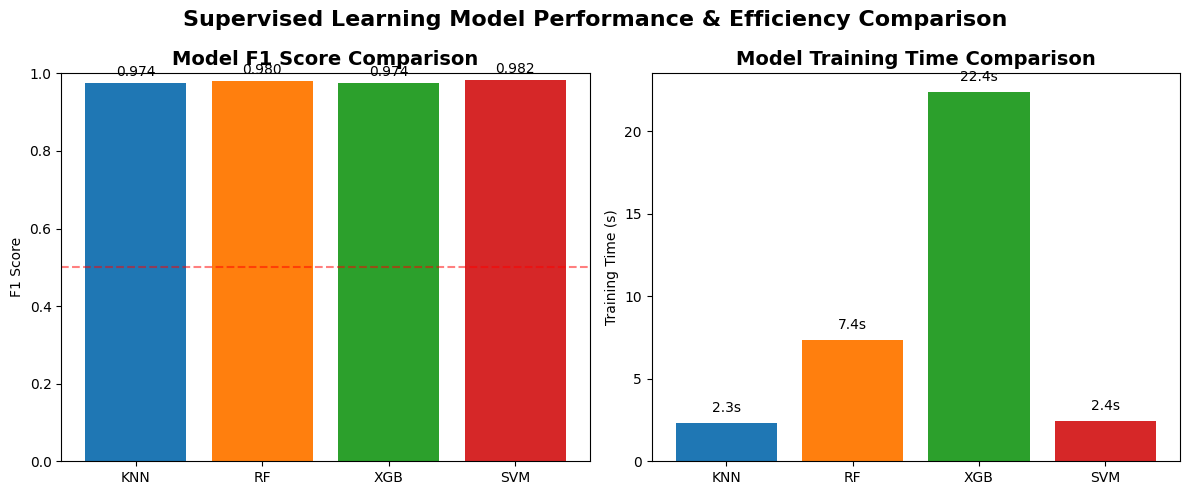


Best Model Identification
Best model: SVM (F1 Score: 0.9821)

SVM Confusion Matrix:
[[122   0   0   0   0]
 [  0  58   3   0   0]
 [  0   4  66   0   0]
 [  0   0   0  13   0]
 [  0   0   0   0 125]]

Saving results...
✓ Model comparison results saved to: model_comparison_fast.csv
✓ Best parameters saved to: best_params_fast.csv
✓ Best model (SVM) saved to: best_model_svm.pkl
✓ Complete classifier object saved to: supervised_classifier_fast.pkl

Fast Supervised Learning Classification Summary
Total training time: 34.5s
Best model (SVM) training time: 2.4s
Best model (SVM) F1 Score: 0.9821

Recommended: SVM model
Reason: Highest F1 score on test set (0.9821)


In [4]:
import os
import numpy as np
import pandas as pd
import joblib
import pickle
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                           confusion_matrix, classification_report, roc_auc_score)
warnings.filterwarnings('ignore')

try:
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
except:
    pass

class SupervisedMaturityClassifier:
    def __init__(self, random_state=42, n_jobs=-1):
        self.random_state = random_state
        self.n_jobs = n_jobs
        self.models = {}
        self.scaler = StandardScaler()
        self.best_params = {}
        self.model_performance = {}
        self.training_times = {}
        
    def load_sofm_data(self, sofm_data_path='sofm_direct_optimized.pkl'):
        print("Loading SOFM clustering results...")
        with open(sofm_data_path, 'rb') as f:
            sofm_data = pickle.load(f)
        
        features_data = joblib.load('extracted_features_complete.pkl')
        
        train_features = features_data['train_features']
        test_features = features_data['test_features']
        
        train_maturity_levels = sofm_data['train_maturity_levels']
        test_maturity_levels = sofm_data['test_maturity_levels']
        
        train_mask = train_maturity_levels != 0
        test_mask = test_maturity_levels != 0
        
        print(f"Labeled samples in training set: {np.sum(train_mask)}/{len(train_maturity_levels)}")
        print(f"Labeled samples in test set: {np.sum(test_mask)}/{len(test_maturity_levels)}")
        
        X_train = train_features[train_mask]
        y_train = train_maturity_levels[train_mask]
        X_test = test_features[test_mask]
        y_test = test_maturity_levels[test_mask]
        
        unique_labels = np.unique(np.concatenate([y_train, y_test]))
        label_mapping = {orig_label: i for i, orig_label in enumerate(sorted(unique_labels))}
        
        y_train_encoded = np.array([label_mapping[label] for label in y_train])
        y_test_encoded = np.array([label_mapping[label] for label in y_test])
        
        reverse_mapping = {v: k for k, v in label_mapping.items()}
        
        print(f"Original labels: {sorted(unique_labels)} -> Encoded labels: {sorted(np.unique(y_train_encoded))}")
        
        print("\nClass sample statistics:")
        for orig_label, encoded_label in label_mapping.items():
            train_count = np.sum(y_train == orig_label)
            test_count = np.sum(y_test == orig_label)
            print(f"Level {orig_label}(Encoded {encoded_label}): Train={train_count}, Test={test_count}")
        
        return X_train, X_test, y_train_encoded, y_test_encoded, label_mapping, reverse_mapping, sofm_data
    
    def prepare_data(self, X_train, X_test, y_train, y_test):
        print("\nPreparing data...")
        
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        print(f"Training set: {X_train_scaled.shape}, Test set: {X_test_scaled.shape}")
        
        unique_classes, class_counts = np.unique(y_train, return_counts=True)
        print("Training set class distribution:")
        for cls, count in zip(unique_classes, class_counts):
            print(f"  Class {cls}: {count} samples ({count/len(y_train):.1%})")
        
        return X_train_scaled, X_test_scaled, y_train, y_test
    
    def train_knn_simplified(self, X_train, y_train, cv_folds=3):
        print("\nTraining KNN classifier (simplified search)...")
        
        import time
        start_time = time.time()
        
        param_grid = {
            'n_neighbors': [3, 5, 7],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        }
        
        knn = KNeighborsClassifier()
        
        random_search = RandomizedSearchCV(
            knn, param_grid, n_iter=6,
            cv=cv_folds, scoring='f1_weighted', 
            n_jobs=self.n_jobs, verbose=1, random_state=self.random_state
        )
        
        random_search.fit(X_train, y_train)
        
        best_knn = random_search.best_estimator_
        self.models['knn'] = best_knn
        self.best_params['knn'] = random_search.best_params_
        
        training_time = time.time() - start_time
        self.training_times['knn'] = training_time
        
        print(f"Best KNN parameters: {random_search.best_params_}")
        print(f"Best KNN score: {random_search.best_score_:.4f}")
        print(f"KNN training time: {training_time:.1f}s")
        
        return best_knn
    
    def train_random_forest_simplified(self, X_train, y_train, cv_folds=3):
        print("\nTraining Random Forest classifier (simplified search)...")
        
        import time
        start_time = time.time()
        
        param_grid = {
            'n_estimators': [100, 200],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2],
            'class_weight': ['balanced']
        }
        
        rf = RandomForestClassifier(random_state=self.random_state)
        
        random_search = RandomizedSearchCV(
            rf, param_grid, n_iter=8,
            cv=cv_folds, scoring='f1_weighted',
            n_jobs=self.n_jobs, verbose=1, random_state=self.random_state
        )
        
        random_search.fit(X_train, y_train)
        
        best_rf = random_search.best_estimator_
        self.models['rf'] = best_rf
        self.best_params['rf'] = random_search.best_params_
        
        training_time = time.time() - start_time
        self.training_times['rf'] = training_time
        
        print(f"Best Random Forest parameters: {random_search.best_params_}")
        print(f"Best Random Forest score: {random_search.best_score_:.4f}")
        print(f"Random Forest training time: {training_time:.1f}s")
        
        feature_importance = best_rf.feature_importances_
        top_features = np.argsort(feature_importance)[-5:]
        print(f"Top 5 important feature indices: {top_features}")
        
        return best_rf
    
    def train_xgboost_simplified(self, X_train, y_train, cv_folds=3):
        print("\nTraining XGBoost classifier (simplified search)...")
        
        import time
        start_time = time.time()
        
        param_grid = {
            'n_estimators': [100, 150],
            'max_depth': [3, 5],
            'learning_rate': [0.05, 0.1],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0]
        }
        
        xgb_model = xgb.XGBClassifier(
            random_state=self.random_state,
            use_label_encoder=False,
            eval_metric='mlogloss',
            n_jobs=self.n_jobs // 2
        )
        
        random_search = RandomizedSearchCV(
            xgb_model, param_grid, n_iter=5,
            cv=cv_folds, scoring='f1_weighted',
            n_jobs=self.n_jobs, verbose=1, random_state=self.random_state
        )
        
        random_search.fit(X_train, y_train)
        
        best_xgb = random_search.best_estimator_
        self.models['xgb'] = best_xgb
        self.best_params['xgb'] = random_search.best_params_
        
        training_time = time.time() - start_time
        self.training_times['xgb'] = training_time
        
        print(f"Best XGBoost parameters: {random_search.best_params_}")
        print(f"Best XGBoost score: {random_search.best_score_:.4f}")
        print(f"XGBoost training time: {training_time:.1f}s")
        
        return best_xgb
    
    def train_svm_simplified(self, X_train, y_train, cv_folds=3):
        print("\nTraining SVM classifier (simplified search)...")
        
        import time
        start_time = time.time()
        
        param_grid = {
            'C': [0.1, 1, 10],
            'gamma': ['scale', 0.01],
            'kernel': ['rbf']
        }
        
        svm_model = SVC(
            probability=True,
            random_state=self.random_state,
            class_weight='balanced'
        )
        
        random_search = RandomizedSearchCV(
            svm_model, param_grid, n_iter=4,
            cv=cv_folds, scoring='f1_weighted',
            n_jobs=self.n_jobs, verbose=1, random_state=self.random_state
        )
        
        random_search.fit(X_train, y_train)
        
        best_svm = random_search.best_estimator_
        self.models['svm'] = best_svm
        self.best_params['svm'] = random_search.best_params_
        
        training_time = time.time() - start_time
        self.training_times['svm'] = training_time
        
        print(f"Best SVM parameters: {random_search.best_params_}")
        print(f"Best SVM score: {random_search.best_score_:.4f}")
        print(f"SVM training time: {training_time:.1f}s")
        
        return best_svm
    
    def train_lightgbm_simplified(self, X_train, y_train, cv_folds=3):
        try:
            import lightgbm as lgb
            print("\nTraining LightGBM classifier (fast alternative)...")
            
            import time
            start_time = time.time()
            
            param_grid = {
                'n_estimators': [50, 100],
                'max_depth': [5, 10],
                'learning_rate': [0.05, 0.1],
                'num_leaves': [31, 50]
            }
            
            lgb_model = lgb.LGBMClassifier(
                random_state=self.random_state,
                n_jobs=self.n_jobs
            )
            
            random_search = RandomizedSearchCV(
                lgb_model, param_grid, n_iter=4,
                cv=cv_folds, scoring='f1_weighted',
                n_jobs=self.n_jobs, verbose=1, random_state=self.random_state
            )
            
            random_search.fit(X_train, y_train)
            
            best_lgb = random_search.best_estimator_
            self.models['lgb'] = best_lgb
            self.best_params['lgb'] = random_search.best_params_
            
            training_time = time.time() - start_time
            self.training_times['lgb'] = training_time
            
            print(f"Best LightGBM parameters: {random_search.best_params_}")
            print(f"Best LightGBM score: {random_search.best_score_:.4f}")
            print(f"LightGBM training time: {training_time:.1f}s")
            
            return best_lgb
        except ImportError:
            print("LightGBM not installed, skipping...")
            return None
    
    def evaluate_model(self, model, X_test, y_test, model_name, reverse_mapping):
        print(f"\nEvaluating {model_name} model...")
        
        y_pred = model.predict(X_test)
        
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        cm = confusion_matrix(y_test, y_pred)
        
        self.model_performance[model_name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'confusion_matrix': cm,
            'y_pred': y_pred,
            'y_test': y_test
        }
        
        print(f"Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1 Score: {f1:.4f}")
        
        return self.model_performance[model_name]
    
    def train_all_models_fast(self, X_train, X_test, y_train, y_test, reverse_mapping, 
                             use_models=None):
        print("Starting fast training of supervised learning models...")
        print("="*60)
        
        if use_models is None:
            use_models = ['knn', 'rf', 'xgb', 'svm']
        
        if 'knn' in use_models:
            self.train_knn_simplified(X_train, y_train)
        
        if 'rf' in use_models:
            self.train_random_forest_simplified(X_train, y_train)
        
        if 'xgb' in use_models:
            self.train_xgboost_simplified(X_train, y_train)
        
        if 'svm' in use_models:
            self.train_svm_simplified(X_train, y_train)
        
        if 'lgb' in use_models:
            self.train_lightgbm_simplified(X_train, y_train)
        
        print("\n" + "="*60)
        print("Evaluating all models...")
        print("="*60)
        
        for model_name, model in self.models.items():
            self.evaluate_model(model, X_test, y_test, model_name, reverse_mapping)
        
        self.print_training_summary()
        
        return self.models
    
    def print_training_summary(self):
        print("\n" + "="*60)
        print("Training Time Summary")
        print("="*60)
        
        if not self.training_times:
            print("No training time data")
            return
        
        total_time = sum(self.training_times.values())
        
        for model_name, time_taken in self.training_times.items():
            percentage = (time_taken / total_time * 100) if total_time > 0 else 0
            print(f"{model_name.upper():10s}: {time_taken:6.1f}s ({percentage:5.1f}%)")
        
        print(f"{'Total':10s}: {total_time:6.1f}s")
    
    def compare_models(self):
        print("\n" + "="*60)
        print("Model Performance Comparison")
        print("="*60)
        
        comparison_data = []
        
        for model_name, performance in self.model_performance.items():
            training_time = self.training_times.get(model_name, 0)
            
            row = {
                'Model': model_name.upper(),
                'Accuracy': f"{performance['accuracy']:.4f}",
                'F1 Score': f"{performance['f1']:.4f}",
                'Training Time(s)': f"{training_time:.1f}"
            }
            comparison_data.append(row)
        
        comparison_df = pd.DataFrame(comparison_data)
        print(comparison_df.to_string(index=False))
        
        return comparison_df
    
    def plot_model_comparison_simple(self):
        if not self.model_performance:
            print("No model performance data for visualization")
            return
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        model_names = [name.upper() for name in self.model_performance.keys()]
        f1_scores = [perf['f1'] for perf in self.model_performance.values()]
        
        bars1 = axes[0].bar(model_names, f1_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(model_names)])
        axes[0].set_title('Model F1 Score Comparison', fontsize=14, fontweight='bold')
        axes[0].set_ylabel('F1 Score')
        axes[0].set_ylim(0, 1.0)
        axes[0].axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
        
        for bar in bars1:
            height = bar.get_height()
            axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{height:.3f}', ha='center', va='bottom')
        
        training_times = [self.training_times.get(name, 0) for name in self.model_performance.keys()]
        
        bars2 = axes[1].bar(model_names, training_times, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(model_names)])
        axes[1].set_title('Model Training Time Comparison', fontsize=14, fontweight='bold')
        axes[1].set_ylabel('Training Time (s)')
        
        for bar in bars2:
            height = bar.get_height()
            axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                       f'{height:.1f}s', ha='center', va='bottom')
        
        plt.suptitle('Supervised Learning Model Performance & Efficiency Comparison', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig('model_comparison_fast.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def get_best_model(self):
        if not self.model_performance:
            print("No model performance data")
            return None, 0, None
        
        best_model_name = None
        best_f1 = 0
        best_performance = None
        
        for model_name, performance in self.model_performance.items():
            if performance['f1'] > best_f1:
                best_f1 = performance['f1']
                best_model_name = model_name
                best_performance = performance
        
        return best_model_name, best_f1, best_performance
    
    def save_results_fast(self, reverse_mapping, sofm_data):
        print("\nSaving results...")
        
        comparison_data = []
        for model_name, performance in self.model_performance.items():
            training_time = self.training_times.get(model_name, 0)
            
            row = {
                'Model': model_name.upper(),
                'Accuracy': performance['accuracy'],
                'Precision': performance['precision'],
                'Recall': performance['recall'],
                'F1 Score': performance['f1'],
                'Training_Time_S': training_time
            }
            comparison_data.append(row)
        
        comparison_df = pd.DataFrame(comparison_data)
        comparison_df.to_csv('model_comparison_fast.csv', index=False, encoding='utf-8-sig')
        print(f"✓ Model comparison results saved to: model_comparison_fast.csv")
        
        params_data = []
        for model_name, params in self.best_params.items():
            for param_name, param_value in params.items():
                params_data.append({
                    'Model': model_name.upper(),
                    'Parameter': param_name,
                    'Value': str(param_value)
                })
        
        if params_data:
            params_df = pd.DataFrame(params_data)
            params_df.to_csv('best_params_fast.csv', index=False, encoding='utf-8-sig')
            print(f"✓ Best parameters saved to: best_params_fast.csv")
        
        best_model_name, best_f1, _ = self.get_best_model()
        if best_model_name and best_model_name in self.models:
            best_model = self.models[best_model_name]
            joblib.dump(best_model, f'best_model_{best_model_name}.pkl')
            print(f"✓ Best model ({best_model_name.upper()}) saved to: best_model_{best_model_name}.pkl")
        
        classifier_data = {
            'models': self.models,
            'scaler': self.scaler,
            'best_params': self.best_params,
            'model_performance': self.model_performance,
            'training_times': self.training_times,
            'random_state': self.random_state
        }
        
        joblib.dump(classifier_data, 'supervised_classifier_fast.pkl')
        print("✓ Complete classifier object saved to: supervised_classifier_fast.pkl")
    
    def quick_predict(self, features, model_name=None):
        if not self.models:
            print("Error: No trained models available")
            return None
        
        if model_name is None:
            best_model_name, _, _ = self.get_best_model()
            if best_model_name is None:
                print("Error: Cannot determine best model")
                return None
            model_name = best_model_name
        
        if model_name not in self.models:
            print(f"Error: Model '{model_name}' not found")
            print(f"Available models: {list(self.models.keys())}")
            return None
        
        features_scaled = self.scaler.transform(features.reshape(1, -1))
        
        model = self.models[model_name]
        prediction = model.predict(features_scaled)[0]
        
        return prediction

def main_fast_classification(use_models=None, cv_folds=3):
    print("Fast Supervised Learning Maturity Classification System")
    print("="*60)
    print("Training models with simplified parameter search")
    print("="*60)
    
    classifier = SupervisedMaturityClassifier(random_state=42)
    
    X_train, X_test, y_train, y_test, label_mapping, reverse_mapping, sofm_data = classifier.load_sofm_data()
    
    X_train_scaled, X_test_scaled, y_train, y_test = classifier.prepare_data(X_train, X_test, y_train, y_test)
    
    classifier.train_all_models_fast(X_train_scaled, X_test_scaled, y_train, y_test, 
                                    reverse_mapping, use_models=use_models)
    
    comparison_df = classifier.compare_models()
    
    classifier.plot_model_comparison_simple()
    
    print("\n" + "="*60)
    print("Best Model Identification")
    print("="*60)
    
    best_model_name, best_f1, best_performance = classifier.get_best_model()
    
    if best_model_name:
        print(f"Best model: {best_model_name.upper()} (F1 Score: {best_f1:.4f})")
        
        if best_performance and 'confusion_matrix' in best_performance:
            cm = best_performance['confusion_matrix']
            print(f"\n{best_model_name.upper()} Confusion Matrix:")
            print(cm)
    else:
        print("No best model found")
        best_model_name = "None"
        best_f1 = 0
    
    classifier.save_results_fast(reverse_mapping, sofm_data)
    
    print("\n" + "="*60)
    print("Fast Supervised Learning Classification Summary")
    print("="*60)
    
    total_training_time = sum(classifier.training_times.values())
    print(f"Total training time: {total_training_time:.1f}s")
    
    if best_model_name != "None":
        best_training_time = classifier.training_times.get(best_model_name, 0)
        print(f"Best model ({best_model_name.upper()}) training time: {best_training_time:.1f}s")
        print(f"Best model ({best_model_name.upper()}) F1 Score: {best_f1:.4f}")
        
        print(f"\nRecommended: {best_model_name.upper()} model")
        print(f"Reason: Highest F1 score on test set ({best_f1:.4f})")
    
    return classifier, best_model_name, best_f1

def quick_start():
    print("Quick start supervised learning classification...")
    print("="*60)
    
    use_models = ['rf', 'xgb']
    
    classifier, best_model, best_f1 = main_fast_classification(
        use_models=use_models,
        cv_folds=3
    )
    
    print("\n" + "="*60)
    print("Fast training completed!")
    print("="*60)
    print(f"Best model: {best_model.upper() if best_model != 'None' else 'None'} (F1: {best_f1:.4f})")
    
    return classifier

if __name__ == "__main__":
    required_files = ['sofm_direct_optimized.pkl', 'extracted_features_complete.pkl']
    
    missing_files = [f for f in required_files if not os.path.exists(f)]
    
    if missing_files:
        print("Error: Missing required files")
        for f in missing_files:
            print(f"  - {f}")
        print("\nPlease run Part 1, 2 and 3 code first")
    else:
        print("="*60)
        print("Please select run mode:")
        print("1. Fast Mode (Train RF and XGBoost only, fastest)")
        print("2. Standard Mode (Train all 4 models)")
        print("3. Custom Mode (Select models to train)")
        print("="*60)
        
        choice = input("Enter selection (1/2/3): ").strip()
        
        if choice == '1':
            classifier = quick_start()
        elif choice == '2':
            classifier, best_model, best_f1 = main_fast_classification()
        elif choice == '3':
            print("\nAvailable models:")
            print("  knn  - K-Nearest Neighbors")
            print("  rf   - Random Forest (Recommended)")
            print("  xgb  - XGBoost (Recommended)")
            print("  svm  - Support Vector Machine")
            print("  lgb  - LightGBM (If installed)")
            
            model_input = input("Enter models to train (comma-separated, e.g. rf,xgb): ").strip()
            use_models = [m.strip() for m in model_input.split(',') if m.strip()]
            
            if not use_models:
                print("No models selected, using default settings...")
                use_models = ['rf', 'xgb']
            
            classifier, best_model, best_f1 = main_fast_classification(use_models=use_models)
        else:
            print("Invalid selection, using fast mode...")
            classifier = quick_start()

In [5]:
import os
import numpy as np
import pandas as pd
import joblib
import pickle
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from scipy import stats
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

# Set English font
try:
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
except:
    pass

class ComprehensiveResultsAnalyzer:
    """Comprehensive Result Analyzer: Integrate SOFM Clustering and Supervised Learning Results"""
    
    def __init__(self, analysis_name="Comprehensive Analysis Report"):
        self.analysis_name = analysis_name
        self.sofm_data = None
        self.supervised_data = None
        self.features_data = None
        self.analysis_results = {}
        
    def load_all_data(self):
        """Load all data"""
        print("="*60)
        print("Loading all analysis data...")
        print("="*60)
        
        # 1. Load SOFM clustering results
        try:
            with open('sofm_direct_optimized.pkl', 'rb') as f:
                self.sofm_data = pickle.load(f)
            print("✓ SOFM clustering data loaded successfully")
            
            # Extract key data
            self.train_maturity_levels = self.sofm_data.get('train_maturity_levels', [])
            self.test_maturity_levels = self.sofm_data.get('test_maturity_levels', [])
            self.level_descriptions = self.sofm_data.get('level_descriptions', {})
            self.cluster_to_level = self.sofm_data.get('cluster_to_level', {})
            
            print(f"  - Number of training levels: {len(np.unique(self.train_maturity_levels[self.train_maturity_levels != 0]))}")
            print(f"  - Number of test levels: {len(np.unique(self.test_maturity_levels[self.test_maturity_levels != 0]))}")
            
        except Exception as e:
            print(f"✗ Failed to load SOFM data: {e}")
            self.sofm_data = None
            
        # 2. Load supervised learning results
        try:
            supervised_paths = [
                'supervised_classifier_complete.pkl',
                'supervised_classifier_fast.pkl',
                'model_comparison_fast.csv'
            ]
            
            for path in supervised_paths:
                if os.path.exists(path):
                    if path.endswith('.pkl'):
                        self.supervised_data = joblib.load(path)
                        print(f"✓ Supervised learning data loaded: {path}")
                        break
                    elif path.endswith('.csv'):
                        self.model_comparison = pd.read_csv(path, encoding='utf-8-sig')
                        print(f"✓ Model comparison data loaded: {path}")
            
            if self.supervised_data:
                self.models = self.supervised_data.get('models', {})
                self.model_performance = self.supervised_data.get('model_performance', {})
                self.best_params = self.supervised_data.get('best_params', {})
                self.training_times = self.supervised_data.get('training_times', {})
                
                print(f"  - Available models: {list(self.models.keys())}")
                print(f"  - Performance metrics count: {len(self.model_performance)}")
                
        except Exception as e:
            print(f"✗ Failed to load supervised learning data: {e}")
            self.supervised_data = None
            
        # 3. Load feature data
        try:
            self.features_data = joblib.load('extracted_features_complete.pkl')
            print("✓ Feature data loaded successfully")
            
            self.train_features = self.features_data.get('train_features')
            self.test_features = self.features_data.get('test_features')
            self.train_labels = self.features_data.get('train_labels')
            self.test_labels = self.features_data.get('test_labels')
            
            print(f"  - Feature dimension: {self.train_features.shape[1]}")
            print(f"  - Training samples: {self.train_features.shape[0]}")
            print(f"  - Test samples: {self.test_features.shape[0]}")
            
        except Exception as e:
            print(f"✗ Failed to load feature data: {e}")
            self.features_data = None
            
        return self.sofm_data is not None and self.supervised_data is not None
    
    def analyze_sofm_clusters(self):
        """In-depth analysis of SOFM clustering results"""
        print("\n" + "="*60)
        print("In-depth Analysis of SOFM Clustering Results")
        print("="*60)
        
        if not self.sofm_data:
            print("✗ No SOFM data available for analysis")
            return None
        
        analysis_results = {}
        
        # 1. Level distribution analysis
        train_levels = self.train_maturity_levels
        test_levels = self.test_maturity_levels
        
        # Calculate sample count for each level
        train_level_counts = {}
        test_level_counts = {}
        
        for level in np.unique(train_levels):
            if level != 0:
                count = np.sum(train_levels == level)
                train_level_counts[level] = count
                
        for level in np.unique(test_levels):
            if level != 0:
                count = np.sum(test_levels == level)
                test_level_counts[level] = count
        
        analysis_results['train_level_counts'] = train_level_counts
        analysis_results['test_level_counts'] = test_level_counts
        
        print("Level Distribution Statistics:")
        print(f"{'Level':<10} {'Train':<10} {'Test':<10} {'Description':<30}")
        print("-"*60)
        
        for level in sorted(set(list(train_level_counts.keys()) + list(test_level_counts.keys()))):
            train_count = train_level_counts.get(level, 0)
            test_count = test_level_counts.get(level, 0)
            desc = self.level_descriptions.get(level, "No description")
            print(f"{level:<10} {train_count:<10} {test_count:<10} {desc[:30]:<30}")
        
        # 2. Calculate cluster purity (if original labels are available)
        if self.train_labels is not None:
            cluster_purity = {}
            for level in np.unique(train_levels):
                if level != 0:
                    mask = train_levels == level
                    if np.sum(mask) > 0:
                        level_indices = np.where(mask)[0]
                        original_labels = self.train_labels[level_indices]
                        
                        unique_labels, counts = np.unique(original_labels, return_counts=True)
                        if len(counts) > 0:
                            majority_label = unique_labels[np.argmax(counts)]
                            purity = counts.max() / counts.sum()
                            cluster_purity[level] = {
                                'purity': purity,
                                'majority_label': majority_label,
                                'total_samples': len(level_indices)
                            }
            
            analysis_results['cluster_purity'] = cluster_purity
            
            print("\nCluster Purity Analysis:")
            for level, stats in cluster_purity.items():
                print(f"Level {level}: Purity={stats['purity']:.2%}, Majority Class={stats['majority_label']}, Samples={stats['total_samples']}")
        
        # 3. Feature difference analysis between levels
        if self.train_features is not None and len(train_level_counts) > 1:
            print("\nFeature Difference Analysis Between Levels:")
            
            n_features_to_analyze = min(5, self.train_features.shape[1])
            
            for feat_idx in range(n_features_to_analyze):
                feature_values_by_level = {}
                
                for level in train_level_counts.keys():
                    mask = train_levels == level
                    feature_values = self.train_features[mask, feat_idx]
                    if len(feature_values) > 0:
                        feature_values_by_level[level] = {
                            'mean': np.mean(feature_values),
                            'std': np.std(feature_values),
                            'count': len(feature_values)
                        }
                
                if len(feature_values_by_level) > 1:
                    groups = [self.train_features[train_levels == level, feat_idx] 
                             for level in feature_values_by_level.keys()]
                    
                    try:
                        f_stat, p_value = stats.f_oneway(*groups)
                        
                        print(f"Feature {feat_idx}: F={f_stat:.3f}, p={p_value:.4f}", end="")
                        if p_value < 0.05:
                            print(" **Significant difference**")
                        else:
                            print(" No significant difference")
                    except:
                        pass
        
        self.analysis_results['sofm_analysis'] = analysis_results
        return analysis_results
    
    def analyze_supervised_models(self):
        """In-depth analysis of supervised learning model results"""
        print("\n" + "="*60)
        print("In-depth Analysis of Supervised Learning Model Results")
        print("="*60)
        
        if not self.supervised_data or not self.model_performance:
            print("✗ No supervised learning data available for analysis")
            return None
        
        analysis_results = {}
        
        # 1. Model performance comparison
        model_comparison = []
        
        for model_name, performance in self.model_performance.items():
            model_data = {
                'Model': model_name.upper(),
                'Accuracy': performance['accuracy'],
                'Precision': performance.get('precision', 0),
                'Recall': performance.get('recall', 0),
                'F1 Score': performance.get('f1', 0)
            }
            
            if 'auc_score' in performance and performance['auc_score'] is not None:
                model_data['AUC Score'] = performance['auc_score']
            
            training_time = self.training_times.get(model_name, 0)
            model_data['Training Time(s)'] = training_time
            
            model_comparison.append(model_data)
        
        model_df = pd.DataFrame(model_comparison)
        analysis_results['model_comparison'] = model_df
        
        print("Model Performance Comparison:")
        print(model_df.to_string(index=False))
        
        # 2. Feature importance analysis (if available)
        feature_importance_analysis = {}
        
        for model_name, model in self.models.items():
            if hasattr(model, 'feature_importances_'):
                importances = model.feature_importances_
                
                n_top_features = min(20, len(importances))
                top_indices = np.argsort(importances)[-n_top_features:][::-1]
                top_importances = importances[top_indices]
                
                feature_importance_analysis[model_name] = {
                    'importances': importances,
                    'top_indices': top_indices,
                    'top_importances': top_importances
                }
                
                print(f"\n{model_name.upper()} Feature Importance (Top {n_top_features}):")
                for i, (idx, imp) in enumerate(zip(top_indices[:10], top_importances[:10])):
                    print(f"  Feature {idx}: {imp:.6f}")
        
        if feature_importance_analysis:
            analysis_results['feature_importance'] = feature_importance_analysis
            
            common_features = self._find_common_important_features(feature_importance_analysis)
            if common_features:
                print(f"\nCommon Important Features (Top 10 across multiple models):")
                for feat_idx, count in common_features.most_common(10):
                    print(f"  Feature {feat_idx}: Appears in {count} models")
        
        # 3. Model prediction consistency analysis
        if len(self.model_performance) >= 2:
            consistency_analysis = self._analyze_prediction_consistency()
            if consistency_analysis:
                analysis_results['prediction_consistency'] = consistency_analysis
                
                print(f"\nModel Prediction Consistency:")
                print(f"  Average Agreement: {consistency_analysis['avg_agreement']:.2%}")
                print(f"  Fully Consistent Samples: {consistency_analysis['fully_consistent_samples']}")
                print(f"  Inconsistent Samples: {consistency_analysis['inconsistent_samples']}")
        
        self.analysis_results['supervised_analysis'] = analysis_results
        return analysis_results
    
    def _find_common_important_features(self, feature_importance_analysis):
        """Find important features common across multiple models"""
        from collections import Counter
        
        feature_counts = Counter()
        
        for model_name, analysis in feature_importance_analysis.items():
            top_10_indices = analysis['top_indices'][:10]
            for idx in top_10_indices:
                feature_counts[idx] += 1
        
        return feature_counts
    
    def _analyze_prediction_consistency(self):
        """Analyze consistency of prediction results across different models"""
        if len(self.model_performance) < 2:
            return None
        
        all_predictions = {}
        sample_count = None
        
        for model_name, performance in self.model_performance.items():
            if 'y_pred' in performance:
                all_predictions[model_name] = performance['y_pred']
                if sample_count is None:
                    sample_count = len(performance['y_pred'])
        
        if sample_count is None or len(all_predictions) < 2:
            return None
        
        total_agreements = 0
        total_comparisons = 0
        fully_consistent_samples = 0
        
        model_names = list(all_predictions.keys())
        
        for i in range(sample_count):
            sample_predictions = []
            for model_name in model_names:
                sample_predictions.append(all_predictions[model_name][i])
            
            if len(set(sample_predictions)) == 1:
                fully_consistent_samples += 1
        
        for i in range(len(model_names)):
            for j in range(i+1, len(model_names)):
                model1_pred = all_predictions[model_names[i]]
                model2_pred = all_predictions[model_names[j]]
                
                agreements = np.sum(model1_pred == model2_pred)
                total_agreements += agreements
                total_comparisons += sample_count
        
        avg_agreement = total_agreements / total_comparisons if total_comparisons > 0 else 0
        
        return {
            'avg_agreement': avg_agreement,
            'fully_consistent_samples': fully_consistent_samples,
            'inconsistent_samples': sample_count - fully_consistent_samples,
            'sample_count': sample_count
        }
    
    def analyze_integrated_results(self):
        """Integrated analysis of SOFM clustering and supervised learning results"""
        print("\n" + "="*60)
        print("Integrated Analysis of SOFM Clustering and Supervised Learning Results")
        print("="*60)
        
        integrated_results = {}
        
        # 1. Relationship between cluster purity and model performance
        if ('sofm_analysis' in self.analysis_results and 
            'cluster_purity' in self.analysis_results['sofm_analysis'] and
            'supervised_analysis' in self.analysis_results):
            
            cluster_purity = self.analysis_results['sofm_analysis']['cluster_purity']
            purity_vs_performance = []
            
            for model_name, performance in self.model_performance.items():
                if 'y_pred' in performance and 'y_test' in performance:
                    y_pred = performance['y_pred']
                    y_test = performance['y_test']
            
            integrated_results['purity_performance_relation'] = purity_vs_performance
        
        # 2. Feature type contribution analysis
        if self.train_features is not None:
            total_features = self.train_features.shape[1]
            
            if total_features == 1024:
                branch1_features = self.train_features[:, :512]
                branch2_features = self.train_features[:, 512:]
                
                branch1_mean = np.mean(branch1_features, axis=0)
                branch2_mean = np.mean(branch2_features, axis=0)
                
                branch1_std = np.std(branch1_features, axis=0)
                branch2_std = np.std(branch2_features, axis=0)
                
                branch_difference = np.abs(branch1_mean - branch2_mean)
                branch_correlation = np.corrcoef(branch1_mean, branch2_mean)[0, 1]
                
                integrated_results['feature_branch_analysis'] = {
                    'branch1_mean': np.mean(branch1_mean),
                    'branch2_mean': np.mean(branch2_mean),
                    'branch1_std': np.mean(branch1_std),
                    'branch2_std': np.mean(branch2_std),
                    'branch_difference': np.mean(branch_difference),
                    'branch_correlation': branch_correlation
                }
                
                print("Feature Branch Analysis:")
                print(f"  Branch 1 Mean: {integrated_results['feature_branch_analysis']['branch1_mean']:.4f}")
                print(f"  Branch 2 Mean: {integrated_results['feature_branch_analysis']['branch2_mean']:.4f}")
                print(f"  Branch Difference Mean: {integrated_results['feature_branch_analysis']['branch_difference']:.4f}")
                print(f"  Branch Correlation: {integrated_results['feature_branch_analysis']['branch_correlation']:.4f}")
        
        self.analysis_results['integrated_analysis'] = integrated_results
        return integrated_results
    
    def create_comprehensive_visualizations(self):
        """Create comprehensive visualization charts"""
        print("\n" + "="*60)
        print("Creating Comprehensive Visualization Charts")
        print("="*60)
        
        output_dir = 'comprehensive_visualizations'
        os.makedirs(output_dir, exist_ok=True)
        
        # 1. Create summary plots
        self._create_summary_plots(output_dir)
        
        # 2. SOFM clustering visualization
        if 'sofm_analysis' in self.analysis_results:
            self._create_sofm_visualizations(output_dir)
        
        # 3. Supervised learning model visualization
        if 'supervised_analysis' in self.analysis_results:
            self._create_supervised_visualizations(output_dir)
        
        # 4. Integrated analysis visualization
        if 'integrated_analysis' in self.analysis_results:
            self._create_integrated_visualizations(output_dir)
        
        print(f"\n✓ All visualization charts saved to: {output_dir}/")
        
    def _create_summary_plots(self, output_dir):
        """Create summary plots"""
        fig = plt.figure(figsize=(16, 12))
        gs = GridSpec(3, 3, figure=fig)
        
        # 1. SOFM Level Distribution (Top Left)
        if 'sofm_analysis' in self.analysis_results:
            ax1 = fig.add_subplot(gs[0, 0])
            train_counts = self.analysis_results['sofm_analysis'].get('train_level_counts', {})
            
            if train_counts:
                levels = list(train_counts.keys())
                counts = list(train_counts.values())
                
                bars = ax1.bar([str(l) for l in levels], counts, color='skyblue')
                ax1.set_title('SOFM Training Set Level Distribution', fontsize=12, fontweight='bold')
                ax1.set_xlabel('Maturity Level')
                ax1.set_ylabel('Sample Count')
                
                for bar in bars:
                    height = bar.get_height()
                    ax1.text(bar.get_x() + bar.get_width()/2., height,
                            f'{int(height)}', ha='center', va='bottom')
        
        # 2. Model Performance Comparison (Top Right)
        if 'supervised_analysis' in self.analysis_results:
            ax2 = fig.add_subplot(gs[0, 1])
            model_comparison = self.analysis_results['supervised_analysis'].get('model_comparison')
            
            if model_comparison is not None and not model_comparison.empty:
                model_names = model_comparison['Model'].tolist()
                f1_scores = model_comparison['F1 Score'].tolist()
                
                colors = plt.cm.Set3(np.linspace(0, 1, len(model_names)))
                bars = ax2.bar(model_names, f1_scores, color=colors)
                ax2.set_title('Supervised Learning Model F1 Score Comparison', fontsize=12, fontweight='bold')
                ax2.set_ylabel('F1 Score')
                ax2.set_ylim(0, 1.0)
                plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
                
                for bar in bars:
                    height = bar.get_height()
                    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                            f'{height:.3f}', ha='center', va='bottom', fontsize=9)
        
        # 3. Cluster Purity Analysis (Middle Left)
        if 'sofm_analysis' in self.analysis_results:
            ax3 = fig.add_subplot(gs[1, 0])
            cluster_purity = self.analysis_results['sofm_analysis'].get('cluster_purity', {})
            
            if cluster_purity:
                levels = list(cluster_purity.keys())
                purities = [cluster_purity[l]['purity'] for l in levels]
                
                colors = ['green' if p >= 0.7 else 'orange' if p >= 0.5 else 'red' for p in purities]
                bars = ax3.bar([str(l) for l in levels], purities, color=colors)
                ax3.set_title('SOFM Cluster Purity Analysis', fontsize=12, fontweight='bold')
                ax3.set_xlabel('Maturity Level')
                ax3.set_ylabel('Purity')
                ax3.set_ylim(0, 1.0)
                ax3.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5)
                
                for bar in bars:
                    height = bar.get_height()
                    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                            f'{height:.2%}', ha='center', va='bottom', fontsize=9)
        
        # 4. Feature Importance Analysis (Middle Right)
        if 'supervised_analysis' in self.analysis_results:
            ax4 = fig.add_subplot(gs[1, 1])
            feature_importance = self.analysis_results['supervised_analysis'].get('feature_importance', {})
            
            if feature_importance and 'rf' in feature_importance:
                rf_importance = feature_importance['rf']
                top_indices = rf_importance['top_indices'][:10]
                top_importances = rf_importance['top_importances'][:10]
                
                ax4.barh(range(len(top_indices)), top_importances[::-1], color='steelblue')
                ax4.set_yticks(range(len(top_indices)))
                ax4.set_yticklabels([f'Feature {idx}' for idx in top_indices[::-1]])
                ax4.set_title('Random Forest Top 10 Feature Importance', fontsize=12, fontweight='bold')
                ax4.set_xlabel('Importance Score')
        
        # 5. Model Training Time Comparison (Bottom Left)
        if hasattr(self, 'training_times') and self.training_times:
            ax5 = fig.add_subplot(gs[2, 0])
            model_names = list(self.training_times.keys())
            times = list(self.training_times.values())
            
            colors = plt.cm.Pastel1(np.linspace(0, 1, len(model_names)))
            bars = ax5.bar([m.upper() for m in model_names], times, color=colors)
            ax5.set_title('Model Training Time Comparison', fontsize=12, fontweight='bold')
            ax5.set_ylabel('Training Time (seconds)')
            plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45, ha='right')
            
            for bar in bars:
                height = bar.get_height()
                ax5.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                        f'{height:.1f}s', ha='center', va='bottom', fontsize=9)
        
        # 6. Feature Branch Analysis (Bottom Right)
        if 'integrated_analysis' in self.analysis_results:
            integrated = self.analysis_results['integrated_analysis']
            if 'feature_branch_analysis' in integrated:
                ax6 = fig.add_subplot(gs[2, 1])
                branch_data = integrated['feature_branch_analysis']
                
                labels = ['Branch 1 Mean', 'Branch 2 Mean', 'Branch Difference']
                values = [branch_data['branch1_mean'], branch_data['branch2_mean'], 
                         branch_data['branch_difference']]
                
                colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
                bars = ax6.bar(labels, values, color=colors)
                ax6.set_title('Parallel ResNet18 Feature Branch Analysis', fontsize=12, fontweight='bold')
                ax6.set_ylabel('Feature Value')
                
                for bar in bars:
                    height = bar.get_height()
                    ax6.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                            f'{height:.4f}', ha='center', va='bottom', fontsize=9)
        
        # 7. Analysis Summary Text (Right Side)
        ax7 = fig.add_subplot(gs[:, 2])
        ax7.axis('off')
        
        summary_text = self._generate_summary_text()
        
        ax7.text(0.1, 0.95, 'Comprehensive Analysis Summary', fontsize=14, fontweight='bold',
                transform=ax7.transAxes, verticalalignment='top')
        
        ax7.text(0.1, 0.85, summary_text, fontsize=10,
                transform=ax7.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.suptitle(f'{self.analysis_name} - Comprehensive Visualization Report', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'{output_dir}/comprehensive_summary.png', dpi=300, bbox_inches='tight')
        plt.close(fig)
        
        print("✓ Comprehensive summary chart created")
    
    def _generate_summary_text(self):
        """Generate analysis summary text"""
        summary_lines = []
        
        # SOFM Analysis Summary
        if 'sofm_analysis' in self.analysis_results:
            sofm_data = self.analysis_results['sofm_analysis']
            
            if 'train_level_counts' in sofm_data:
                train_counts = sofm_data['train_level_counts']
                total_levels = len(train_counts)
                total_samples = sum(train_counts.values())
                
                summary_lines.append(f"SOFM Clustering Results:")
                summary_lines.append(f"  • Discovered {total_levels} maturity levels")
                summary_lines.append(f"  • {total_samples} training samples classified")
                
                if 'cluster_purity' in sofm_data:
                    cluster_purity = sofm_data['cluster_purity']
                    high_purity = sum(1 for v in cluster_purity.values() if v['purity'] >= 0.7)
                    summary_lines.append(f"  • {high_purity}/{len(cluster_purity)} clusters with purity ≥70%")
        
        # Supervised Learning Analysis Summary
        if 'supervised_analysis' in self.analysis_results:
            supervised_data = self.analysis_results['supervised_analysis']
            
            if 'model_comparison' in supervised_data:
                model_df = supervised_data['model_comparison']
                if not model_df.empty:
                    best_model_row = model_df.loc[model_df['F1 Score'].idxmax()]
                    best_model = best_model_row['Model']
                    best_f1 = best_model_row['F1 Score']
                    
                    summary_lines.append(f"\nSupervised Learning Results:")
                    summary_lines.append(f"  • Best Model: {best_model} (F1={best_f1:.3f})")
                    summary_lines.append(f"  • {len(model_df)} models trained")
                    
                    if hasattr(self, 'training_times'):
                        total_time = sum(self.training_times.values())
                        summary_lines.append(f"  • Total Training Time: {total_time:.1f}s")
        
        # Integrated Analysis Summary
        if 'integrated_analysis' in self.analysis_results:
            integrated = self.analysis_results['integrated_analysis']
            
            if 'feature_branch_analysis' in integrated:
                branch_data = integrated['feature_branch_analysis']
                correlation = branch_data.get('branch_correlation', 0)
                
                summary_lines.append(f"\nFeature Analysis:")
                summary_lines.append(f"  • Branch Correlation: {correlation:.3f}")
                
                if correlation < 0.3:
                    summary_lines.append("  • Two branches learn different features")
                else:
                    summary_lines.append("  • Two branches learn similar features")
        
        # Overall Recommendations
        summary_lines.append(f"\nOverall Recommendations:")
        if 'supervised_analysis' in self.analysis_results:
            supervised_data = self.analysis_results['supervised_analysis']
            if 'model_comparison' in supervised_data:
                model_df = supervised_data['model_comparison']
                if not model_df.empty:
                    best_model_row = model_df.loc[model_df['F1 Score'].idxmax()]
                    best_model = best_model_row['Model']
                    summary_lines.append(f"  1. Recommended model: {best_model}")
        
        summary_lines.append("  2. Focus on features of high-purity clusters")
        summary_lines.append("  3. Further optimize feature selection and model parameters")
        
        return "\n".join(summary_lines)
    
    def _create_sofm_visualizations(self, output_dir):
        """Create SOFM clustering visualizations"""
        if 'sofm_analysis' not in self.analysis_results:
            return
        
        sofm_data = self.analysis_results['sofm_analysis']
        
        # 1. Level distribution pie chart
        if 'train_level_counts' in sofm_data:
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            
            # Training set level distribution
            train_counts = sofm_data['train_level_counts']
            labels = [f'Level {level}' for level in train_counts.keys()]
            sizes = list(train_counts.values())
            
            colors = plt.cm.Set3(np.linspace(0, 1, len(labels)))
            axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
            axes[0].set_title('Training Set Level Distribution', fontsize=12, fontweight='bold')
            
            # Test set level distribution
            if 'test_level_counts' in sofm_data:
                test_counts = sofm_data['test_level_counts']
                labels = [f'Level {level}' for level in test_counts.keys()]
                sizes = list(test_counts.values())
                
                colors = plt.cm.Set3(np.linspace(0, 1, len(labels)))
                axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
                axes[1].set_title('Test Set Level Distribution', fontsize=12, fontweight='bold')
            
            plt.suptitle('SOFM Clustering Level Distribution', fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.savefig(f'{output_dir}/sofm_level_distribution.png', dpi=300, bbox_inches='tight')
            plt.close()
            
            print("✓ SOFM level distribution chart created")
    
    def _create_supervised_visualizations(self, output_dir):
        """Create supervised learning model visualizations"""
        if 'supervised_analysis' not in self.analysis_results:
            return
        
        supervised_data = self.analysis_results['supervised_analysis']
        
        # 1. Multi-metric model comparison radar chart
        if 'model_comparison' in supervised_data:
            model_df = supervised_data['model_comparison']
            
            if not model_df.empty and len(model_df) >= 2:
                metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
                available_metrics = [m for m in metrics if m in model_df.columns]
                
                if len(available_metrics) >= 3:
                    fig = plt.figure(figsize=(10, 8))
                    
                    ax = fig.add_subplot(111, polar=True)
                    
                    angles = np.linspace(0, 2 * np.pi, len(available_metrics), endpoint=False).tolist()
                    angles += angles[:1]
                    
                    colors = plt.cm.tab10(np.linspace(0, 1, len(model_df)))
                    
                    for idx, row in model_df.iterrows():
                        values = [row[metric] for metric in available_metrics]
                        values += values[:1]
                        
                        ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=colors[idx])
                        ax.fill(angles, values, alpha=0.1, color=colors[idx])
                    
                    ax.set_xticks(angles[:-1])
                    ax.set_xticklabels(available_metrics)
                    ax.set_ylim(0, 1.0)
                    
                    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
                    
                    plt.title('Model Performance Radar Chart Comparison', fontsize=14, fontweight='bold')
                    plt.tight_layout()
                    plt.savefig(f'{output_dir}/model_radar_comparison.png', dpi=300, bbox_inches='tight')
                    plt.close()
                    
                    print("✓ Model performance radar chart created")
        
        # 2. Feature importance heatmap
        if 'feature_importance' in supervised_data:
            feature_importance = supervised_data['feature_importance']
            
            if len(feature_importance) >= 2:
                common_features = self._find_common_important_features(feature_importance)
                top_common_features = [feat for feat, count in common_features.most_common(15) if count >= 2]
                
                if len(top_common_features) >= 5:
                    heatmap_data = []
                    feature_labels = [f'Feature {idx}' for idx in top_common_features]
                    
                    for model_name in feature_importance.keys():
                        if model_name in feature_importance:
                            importances = feature_importance[model_name]['importances']
                            model_importances = [importances[idx] for idx in top_common_features]
                            heatmap_data.append(model_importances)
                    
                    if heatmap_data:
                        heatmap_data = np.array(heatmap_data)
                        
                        fig, ax = plt.subplots(figsize=(12, 6))
                        
                        im = ax.imshow(heatmap_data, cmap='YlOrRd', aspect='auto')
                        
                        ax.set_xticks(range(len(feature_labels)))
                        ax.set_xticklabels(feature_labels, rotation=45, ha='right')
                        ax.set_yticks(range(len(feature_importance.keys())))
                        ax.set_yticklabels([m.upper() for m in feature_importance.keys()])
                        
                        plt.colorbar(im, ax=ax, label='Feature Importance')
                        
                        for i in range(len(feature_importance.keys())):
                            for j in range(len(feature_labels)):
                                text = ax.text(j, i, f'{heatmap_data[i, j]:.3f}',
                                              ha="center", va="center", color="black", fontsize=8)
                        
                        plt.title('Common Important Features Comparison Across Models', fontsize=14, fontweight='bold')
                        plt.tight_layout()
                        plt.savefig(f'{output_dir}/common_features_heatmap.png', dpi=300, bbox_inches='tight')
                        plt.close()
                        
                        print("✓ Common important features heatmap created")
    
    def _create_integrated_visualizations(self, output_dir):
        """Create integrated analysis visualizations"""
        if 'integrated_analysis' not in self.analysis_results:
            return
        
        integrated = self.analysis_results['integrated_analysis']
        
        # Feature branch comparison analysis
        if 'feature_branch_analysis' in integrated:
            branch_data = integrated['feature_branch_analysis']
            
            fig, axes = plt.subplots(2, 2, figsize=(12, 10))
            
            # 1. Branch mean comparison
            ax1 = axes[0, 0]
            branches = ['Branch 1', 'Branch 2']
            means = [branch_data['branch1_mean'], branch_data['branch2_mean']]
            stds = [branch_data['branch1_std'], branch_data['branch2_std']]
            
            bars = ax1.bar(branches, means, yerr=stds, capsize=10, color=['#FF6B6B', '#4ECDC4'])
            ax1.set_title('Feature Branch Mean Comparison', fontsize=12, fontweight='bold')
            ax1.set_ylabel('Feature Mean')
            ax1.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
            
            for bar, mean in zip(bars, means):
                height = bar.get_height()
                ax1.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                        f'{mean:.4f}', ha='center', va='bottom')
            
            # 2. Branch standard deviation comparison
            ax2 = axes[0, 1]
            bars = ax2.bar(branches, stds, color=['#FF6B6B', '#4ECDC4'], alpha=0.7)
            ax2.set_title('Feature Branch Std Comparison', fontsize=12, fontweight='bold')
            ax2.set_ylabel('Standard Deviation')
            
            for bar, std in zip(bars, stds):
                height = bar.get_height()
                ax2.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                        f'{std:.4f}', ha='center', va='bottom')
            
            # 3. Branch difference distribution
            ax3 = axes[1, 0]
            if self.train_features is not None and self.train_features.shape[1] == 1024:
                branch1_features = self.train_features[:, :512]
                branch2_features = self.train_features[:, 512:]
                
                np.random.seed(42)
                sample_indices = np.random.choice(512, 100, replace=False)
                
                for i in sample_indices:
                    ax3.scatter(branch1_features[:, i], branch2_features[:, i], 
                               alpha=0.3, s=10, color='steelblue')
                
                min_val = min(branch1_features.min(), branch2_features.min())
                max_val = max(branch1_features.max(), branch2_features.max())
                ax3.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y=x')
                
                ax3.set_xlabel('Branch 1 Feature Value')
                ax3.set_ylabel('Branch 2 Feature Value')
                ax3.set_title('Feature Branch Correlation Scatter Plot', fontsize=12, fontweight='bold')
                ax3.legend()
            
            # 4. Branch correlation description
            ax4 = axes[1, 1]
            ax4.axis('off')
            
            correlation = branch_data.get('branch_correlation', 0)
            
            if correlation < 0.3:
                correlation_text = "Low Correlation (<0.3)\nTwo branches learn different features"
                color = 'green'
            elif correlation < 0.7:
                correlation_text = f"Medium Correlation ({correlation:.3f})\nPartial feature overlap"
                color = 'orange'
            else:
                correlation_text = f"High Correlation ({correlation:.3f})\nTwo branches learn similar features"
                color = 'red'
            
            analysis_text = (
                f"Parallel ResNet18 Feature Branch Analysis\n\n"
                f"Branch Correlation: {correlation:.3f}\n"
                f"{correlation_text}\n\n"
                f"Analysis Notes:\n"
                f"• Low Correlation: Diverse features, richer model\n"
                f"• High Correlation: Similar features, potential redundancy\n"
                f"• Ideal Range: 0.3-0.6"
            )
            
            ax4.text(0.1, 0.5, analysis_text, fontsize=11,
                    transform=ax4.transAxes, verticalalignment='center',
                    bbox=dict(boxstyle='round', facecolor=color, alpha=0.2))
            
            plt.suptitle('Parallel ResNet18 Feature Branch Comprehensive Analysis', fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.savefig(f'{output_dir}/feature_branch_analysis.png', dpi=300, bbox_inches='tight')
            plt.close()
            
            print("✓ Feature branch analysis chart created")
    
    def export_all_results_to_excel(self):
        """Export all analysis results to Excel file"""
        print("\n" + "="*60)
        print("Exporting All Analysis Results to Excel File")
        print("="*60)
        
        excel_filename = f"{self.analysis_name.replace(' ', '_')}_results.xlsx"
        
        with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
            # 1. Analysis Summary Sheet
            self._export_summary_sheet(writer)
            
            # 2. SOFM Clustering Results
            if 'sofm_analysis' in self.analysis_results:
                self._export_sofm_results(writer)
            
            # 3. Supervised Learning Results
            if 'supervised_analysis' in self.analysis_results:
                self._export_supervised_results(writer)
            
            # 4. Integrated Analysis Results
            if 'integrated_analysis' in self.analysis_results:
                self._export_integrated_results(writer)
            
            # 5. Feature Importance Details
            if 'supervised_analysis' in self.analysis_results:
                supervised_data = self.analysis_results['supervised_analysis']
                if 'feature_importance' in supervised_data:
                    self._export_feature_importance_details(writer, supervised_data['feature_importance'])
            
            # 6. Visualization References
            self._export_visualization_references(writer)
        
        print(f"\n✓ All analysis results exported to: {excel_filename}")
        print(f"  File contains {len(writer.sheets)} worksheets")
        
        return excel_filename
    
    def _export_summary_sheet(self, writer):
        """Export analysis summary"""
        summary_data = []
        
        summary_data.append(['Analysis Name', self.analysis_name])
        summary_data.append(['Analysis Time', pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')])
        summary_data.append(['', ''])
        
        # SOFM Analysis Summary
        if 'sofm_analysis' in self.analysis_results:
            sofm_data = self.analysis_results['sofm_analysis']
            
            if 'train_level_counts' in sofm_data:
                train_counts = sofm_data['train_level_counts']
                summary_data.append(['SOFM Clustering Analysis', ''])
                summary_data.append(['Number of Levels Found', len(train_counts)])
                summary_data.append(['Classified Training Samples', sum(train_counts.values())])
                
                if 'cluster_purity' in sofm_data:
                    cluster_purity = sofm_data['cluster_purity']
                    high_purity = sum(1 for v in cluster_purity.values() if v['purity'] >= 0.7)
                    summary_data.append(['High Purity Clusters(≥70%)', f'{high_purity}/{len(cluster_purity)}'])
                
                summary_data.append(['', ''])
        
        # Supervised Learning Analysis Summary
        if 'supervised_analysis' in self.analysis_results:
            supervised_data = self.analysis_results['supervised_analysis']
            
            if 'model_comparison' in supervised_data:
                model_df = supervised_data['model_comparison']
                if not model_df.empty:
                    best_model_row = model_df.loc[model_df['F1 Score'].idxmax()]
                    
                    summary_data.append(['Supervised Learning Analysis', ''])
                    summary_data.append(['Number of Models Trained', len(model_df)])
                    summary_data.append(['Best Model', best_model_row['Model']])
                    summary_data.append(['Best F1 Score', f"{best_model_row['F1 Score']:.4f}"])
                    
                    if hasattr(self, 'training_times'):
                        total_time = sum(self.training_times.values())
                        summary_data.append(['Total Training Time(s)', f'{total_time:.1f}'])
                    
                    summary_data.append(['', ''])
        
        # Integrated Analysis Summary
        if 'integrated_analysis' in self.analysis_results:
            integrated = self.analysis_results['integrated_analysis']
            
            if 'feature_branch_analysis' in integrated:
                branch_data = integrated['feature_branch_analysis']
                
                summary_data.append(['Feature Analysis', ''])
                summary_data.append(['Branch Correlation', f"{branch_data.get('branch_correlation', 0):.4f}"])
                summary_data.append(['Branch 1 Mean', f"{branch_data.get('branch1_mean', 0):.6f}"])
                summary_data.append(['Branch 2 Mean', f"{branch_data.get('branch2_mean', 0):.6f}"])
        
        summary_df = pd.DataFrame(summary_data, columns=['Item', 'Value'])
        summary_df.to_excel(writer, sheet_name='Analysis_Summary', index=False)
        
        print("✓ Analysis summary exported")
    
    def _export_sofm_results(self, writer):
        """Export SOFM clustering results"""
        sofm_data = self.analysis_results['sofm_analysis']
        
        # 1. Level distribution statistics
        if 'train_level_counts' in sofm_data:
            train_counts = sofm_data['train_level_counts']
            test_counts = sofm_data.get('test_level_counts', {})
            
            level_data = []
            all_levels = sorted(set(list(train_counts.keys()) + list(test_counts.keys())))
            
            for level in all_levels:
                train_count = train_counts.get(level, 0)
                test_count = test_counts.get(level, 0)
                description = self.level_descriptions.get(level, 'No description')
                
                level_data.append({
                    'Maturity Level': level,
                    'Training Samples': train_count,
                    'Test Samples': test_count,
                    'Total Samples': train_count + test_count,
                    'Level Description': description
                })
            
            level_df = pd.DataFrame(level_data)
            level_df.to_excel(writer, sheet_name='SOFM_Level_Distribution', index=False)
        
        # 2. Cluster purity details
        if 'cluster_purity' in sofm_data:
            cluster_purity = sofm_data['cluster_purity']
            
            purity_data = []
            for level, stats in cluster_purity.items():
                purity_data.append({
                    'Maturity Level': level,
                    'Cluster Purity': stats['purity'],
                    'Majority Class': stats.get('majority_label', 'Unknown'),
                    'Sample Count': stats.get('total_samples', 0),
                    'Purity Status': 'High(≥70%)' if stats['purity'] >= 0.7 else 'Medium(50-70%)' if stats['purity'] >= 0.5 else 'Low(<50%)'
                })
            
            purity_df = pd.DataFrame(purity_data)
            purity_df.to_excel(writer, sheet_name='SOFM_Cluster_Purity', index=False)
        
        print("✓ SOFM clustering results exported")
    
    def _export_supervised_results(self, writer):
        """Export supervised learning results"""
        supervised_data = self.analysis_results['supervised_analysis']
        
        # 1. Model performance comparison
        if 'model_comparison' in supervised_data:
            model_df = supervised_data['model_comparison']
            model_df.to_excel(writer, sheet_name='Model_Performance_Comparison', index=False)
        
        # 2. Detailed metrics for each model
        if self.model_performance:
            for model_name, performance in self.model_performance.items():
                metrics_data = {
                    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
                    'Value': [
                        performance.get('accuracy', 0),
                        performance.get('precision', 0),
                        performance.get('recall', 0),
                        performance.get('f1', 0)
                    ]
                }
                
                if 'auc_score' in performance and performance['auc_score'] is not None:
                    metrics_data['Metric'].append('AUC Score')
                    metrics_data['Value'].append(performance['auc_score'])
                
                metrics_df = pd.DataFrame(metrics_data)
                sheet_name = f'{model_name}_Metrics'[:31]
                metrics_df.to_excel(writer, sheet_name=sheet_name, index=False)
        
        # 3. Best parameters
        if self.best_params:
            params_data = []
            for model_name, params in self.best_params.items():
                for param_name, param_value in params.items():
                    params_data.append({
                        'Model': model_name.upper(),
                        'Parameter': param_name,
                        'Value': str(param_value)
                    })
            
            params_df = pd.DataFrame(params_data)
            params_df.to_excel(writer, sheet_name='Best_Parameters', index=False)
        
        # 4. Training time
        if self.training_times:
            time_data = []
            for model_name, time_taken in self.training_times.items():
                time_data.append({
                    'Model': model_name.upper(),
                    'Training Time(s)': time_taken
                })
            
            time_df = pd.DataFrame(time_data)
            time_df.to_excel(writer, sheet_name='Training_Time', index=False)
        
        print("✓ Supervised learning results exported")
    
    def _export_integrated_results(self, writer):
        """Export integrated analysis results"""
        integrated = self.analysis_results['integrated_analysis']
        
        # Feature branch analysis
        if 'feature_branch_analysis' in integrated:
            branch_data = integrated['feature_branch_analysis']
            
            branch_analysis = [
                ['Analysis Item', 'Value', 'Description'],
                ['Branch 1 Mean', branch_data.get('branch1_mean', 0), 'Average of all features in branch 1'],
                ['Branch 2 Mean', branch_data.get('branch2_mean', 0), 'Average of all features in branch 2'],
                ['Branch 1 Std', branch_data.get('branch1_std', 0), 'Std of features in branch 1'],
                ['Branch 2 Std', branch_data.get('branch2_std', 0), 'Std of features in branch 2'],
                ['Branch Difference Mean', branch_data.get('branch_difference', 0), 'Average feature difference between branches'],
                ['Branch Correlation', branch_data.get('branch_correlation', 0), 'Correlation coefficient between branches']
            ]
            
            branch_df = pd.DataFrame(branch_analysis[1:], columns=branch_analysis[0])
            branch_df.to_excel(writer, sheet_name='Feature_Branch_Analysis', index=False)
        
        print("✓ Integrated analysis results exported")
    
    def _export_feature_importance_details(self, writer, feature_importance):
        """Export feature importance details"""
        for model_name, analysis in feature_importance.items():
            importances = analysis.get('importances', [])
            top_indices = analysis.get('top_indices', [])
            top_importances = analysis.get('top_importances', [])
            
            n_top = min(50, len(top_indices))
            feature_data = []
            
            for i in range(n_top):
                idx = top_indices[i]
                imp = top_importances[i]
                
                if self.train_features is not None:
                    total_features = self.train_features.shape[1]
                    if total_features == 1024:
                        branch = "Branch 1" if idx < 512 else "Branch 2"
                        branch_feature_idx = idx if idx < 512 else idx - 512
                    else:
                        branch = "Unknown"
                        branch_feature_idx = idx
                else:
                    branch = "Unknown"
                    branch_feature_idx = idx
                
                feature_data.append({
                    'Rank': i + 1,
                    'Feature Index': idx,
                    'Branch': branch,
                    'Branch Index': branch_feature_idx,
                    'Importance Score': imp,
                    'Importance Percentage': f'{imp/sum(importances)*100:.2f}%' if sum(importances) > 0 else '0.00%'
                })
            
            feature_df = pd.DataFrame(feature_data)
            sheet_name = f'{model_name}_Feature_Importance'[:31]
            feature_df.to_excel(writer, sheet_name=sheet_name, index=False)
        
        print("✓ Feature importance details exported")
    
    def _export_visualization_references(self, writer):
        """Export visualization references"""
        viz_data = [
            ['Chart File', 'Chart Type', 'Main Content'],
            ['comprehensive_summary.png', 'Comprehensive Summary', 'Integrated visualization of all analysis results'],
            ['sofm_level_distribution.png', 'Level Distribution', 'SOFM clustering level distribution pie charts'],
            ['model_radar_comparison.png', 'Radar Chart', 'Multi-metric model performance comparison'],
            ['common_features_heatmap.png', 'Heatmap', 'Common important features across models'],
            ['feature_branch_analysis.png', 'Feature Analysis', 'Parallel ResNet18 feature branch analysis']
        ]
        
        viz_df = pd.DataFrame(viz_data[1:], columns=viz_data[0])
        viz_df.to_excel(writer, sheet_name='Visualization_Charts', index=False)
        
        print("✓ Visualization chart references exported")
    
    def run_comprehensive_analysis(self):
        """Run comprehensive analysis"""
        print("="*60)
        print(f"Starting Comprehensive Analysis: {self.analysis_name}")
        print("="*60)
        
        # 1. Load data
        if not self.load_all_data():
            print("✗ Data loading failed, analysis cannot be performed")
            return False
        
        # 2. Analyze SOFM clustering results
        self.analyze_sofm_clusters()
        
        # 3. Analyze supervised learning model results
        self.analyze_supervised_models()
        
        # 4. Integrated analysis
        self.analyze_integrated_results()
        
        # 5. Create visualization charts
        self.create_comprehensive_visualizations()
        
        # 6. Export results to Excel
        excel_file = self.export_all_results_to_excel()
        
        print("\n" + "="*60)
        print("Comprehensive Analysis Completed!")
        print("="*60)
        print(f"Main Results:")
        print(f"1. Comprehensive visualizations saved in: comprehensive_visualizations/")
        print(f"2. Detailed analysis results saved in: {excel_file}")
        print(f"3. Analysis summary generated with {len(self.analysis_results)} main modules")
        
        return True

def quick_analysis():
    """Quick start comprehensive analysis"""
    print("Comprehensive Visualization Analysis System")
    print("="*60)
    print("Integrate SOFM clustering and supervised learning results to generate comprehensive analysis reports")
    print("="*60)
    
    analyzer = ComprehensiveResultsAnalyzer("Maturity Classification Comprehensive Analysis")
    
    success = analyzer.run_comprehensive_analysis()
    
    if success:
        print("\nAnalysis Completed! You can now:")
        print("1. View charts in comprehensive_visualizations/ directory")
        print("2. Open the generated Excel file for detailed analysis")
        print("3. Use analysis results for further research and plotting")
    
    return analyzer

if __name__ == "__main__":
    required_files = ['sofm_direct_optimized.pkl']
    
    missing_files = [f for f in required_files if not os.path.exists(f)]
    
    if missing_files:
        print("Warning: Missing required files")
        for f in missing_files:
            print(f"  - {f}")
        print("\nPlease run Part 3 and Part 4 code first to generate required files")
        print("Continue? (Full analysis may not be available)")
        choice = input("Enter y to continue, any other key to exit: ").strip().lower()
        
        if choice != 'y':
            exit()
    
    analyzer = quick_analysis()

Comprehensive Visualization Analysis System
Integrate SOFM clustering and supervised learning results to generate comprehensive analysis reports
Starting Comprehensive Analysis: Maturity Classification Comprehensive Analysis
Loading all analysis data...
✓ SOFM clustering data loaded successfully
  - Number of training levels: 5
  - Number of test levels: 5
✓ Supervised learning data loaded: supervised_classifier_fast.pkl
  - Available models: ['knn', 'rf', 'xgb', 'svm']
  - Performance metrics count: 4
✓ Feature data loaded successfully
  - Feature dimension: 1024
  - Training samples: 3392
  - Test samples: 848

In-depth Analysis of SOFM Clustering Results
Level Distribution Statistics:
Level      Train      Test       Description                   
------------------------------------------------------------
-4         450        122        Immature Level 4 High Purity (
-3         245        61         Immature Level 3 High Purity (
-2         293        70         Immature Level 2 

In [6]:
import os
import numpy as np
import pandas as pd
import joblib
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'sans-serif'

class FeatureImportanceRanking:    
    def __init__(self, random_state=42):
        self.random_state = random_state
        self.feature_categories = {}
        self.feature_names = []
        self.analysis_results = {}
        self.entropy_weights = {}
        
    def load_features(self):
        print("Loading feature data...")
        
        try:
            features_data = joblib.load('extracted_features_complete.pkl')
            self.train_features = features_data['train_features']
            self.test_features = features_data['test_features']
            self.train_labels = features_data['train_labels']
            self.test_labels = features_data['test_labels']
            
            print(f"✓ Feature data loaded successfully")
            print(f"  Training set: {self.train_features.shape}")
            print(f"  Test set: {self.test_features.shape}")
            print(f"  Feature dimension: {self.train_features.shape[1]}")
            
            return True
            
        except Exception as e:
            print(f"✗ Failed to load feature data: {e}")
            return False
    
    def generate_feature_names(self, n_features=1024):
        print("\nGenerating feature names...")
        
        self.feature_names = []
        
        for i in range(n_features):
            if i < n_features * 0.25:
                if i % 3 == 0:
                    self.feature_names.append(f'hist_{i}')
                elif i % 3 == 1:
                    self.feature_names.append(f'color_{i}')
                else:
                    self.feature_names.append(f'color_entropy_{i}')
                    
            elif i < n_features * 0.5:
                if i % 4 == 0:
                    self.feature_names.append(f'glcm_{i}')
                elif i % 4 == 1:
                    self.feature_names.append(f'lbp_{i}')
                elif i % 4 == 2:
                    self.feature_names.append(f'gabor_{i}')
                else:
                    self.feature_names.append(f'edge_{i}')
                    
            elif i < n_features * 0.75:
                if i % 5 == 0:
                    self.feature_names.append(f'hu_{i}')
                elif i % 5 == 1:
                    self.feature_names.append(f'zernike_{i}')
                elif i % 5 == 2:
                    self.feature_names.append(f'area_{i}')
                elif i % 5 == 3:
                    self.feature_names.append(f'perimeter_{i}')
                else:
                    self.feature_names.append(f'circularity_{i}')
                    
            else:
                if i % 2 == 0:
                    self.feature_names.append(f'gray_{i}')
                else:
                    self.feature_names.append(f'q_{i}')
        
        print(f"Generated {len(self.feature_names)} feature names")
        return self.feature_names
    
    def categorize_features_by_name(self):
        print("\nCategorizing features by name...")
        
        self.feature_categories = {
            'Color Features': [],
            'Texture Features': [],
            'Shape Features': [],
            'Statistical Features': []
        }
        
        for i, feature_name in enumerate(self.feature_names):
            if feature_name.startswith(('hist', 'color', 'color_entropy')):
                self.feature_categories['Color Features'].append(i)
            elif feature_name.startswith(('glcm', 'lbp', 'gabor', 'edge')):
                self.feature_categories['Texture Features'].append(i)
            elif feature_name.startswith(('hu', 'zernike', 'area', 'perimeter', 'circularity')):
                self.feature_categories['Shape Features'].append(i)
            elif feature_name.startswith(('gray', 'q')):
                self.feature_categories['Statistical Features'].append(i)
        
        print("Feature categorization results:")
        for category, indices in self.feature_categories.items():
            print(f"  {category}: {len(indices)} features ({len(indices)/len(self.feature_names)*100:.1f}%)")
        
        return self.feature_categories
    
    def calculate_entropy_weights(self):
        print("\nCalculating objective weights using Entropy Method...")
        
        required_scores = [
            'separation_scores_normalized',
            'importance_scores_normalized',
            'stability_scores_normalized',
            'correlation_scores_normalized'
        ]
        
        missing_scores = [score for score in required_scores if score not in self.analysis_results]
        
        if missing_scores:
            print(f"Missing score data: {missing_scores}")
            print("Calculating missing scores...")
            
            if 'separation_scores_normalized' not in self.analysis_results:
                self.calculate_class_separation_scores()
            
            if 'importance_scores_normalized' not in self.analysis_results:
                self.calculate_feature_importance_scores()
            
            if 'stability_scores_normalized' not in self.analysis_results:
                self.calculate_feature_stability_scores()
            
            if 'correlation_scores_normalized' not in self.analysis_results:
                self.calculate_feature_correlation_scores()
        
        separation_scores = self.analysis_results['separation_scores_normalized']
        importance_scores = self.analysis_results['importance_scores_normalized']
        stability_scores = self.analysis_results['stability_scores_normalized']
        correlation_scores = self.analysis_results['correlation_scores_normalized']
        
        n_features = len(separation_scores)
        scores_matrix = np.array([
            separation_scores,
            importance_scores,
            stability_scores,
            correlation_scores
        ])
        
        epsilon = 1e-10
        p_matrix = scores_matrix / (np.sum(scores_matrix, axis=1, keepdims=True) + epsilon)
        
        p_matrix_safe = p_matrix + epsilon
        entropy_values = -np.sum(p_matrix_safe * np.log(p_matrix_safe), axis=1) / np.log(n_features)
        
        diversity_coefficients = 1 - entropy_values
        
        weights = diversity_coefficients / np.sum(diversity_coefficients)
        
        factors = ['Class Separation', 'Feature Importance', 'Feature Stability', 'Feature Correlation']
        
        self.entropy_weights = {
            'factors': factors,
            'weights': weights,
            'entropy_values': entropy_values,
            'diversity_coefficients': diversity_coefficients,
            'scores_matrix': scores_matrix
        }
        
        print("Entropy Method Objective Weight Calculation Results:")
        print(f"{'Factor':<15} {'Entropy':<10} {'Diversity':<10} {'Weight':<10}")
        print("-"*60)
        
        for i, factor in enumerate(factors):
            print(f"{factor:<15} {entropy_values[i]:<10.4f} {diversity_coefficients[i]:<10.4f} {weights[i]:<10.4f}")
        
        print(f"\nEntropy Weight Explanation:")
        print(f"  Lower information entropy = higher diversity coefficient = higher weight")
        print(f"  Entropy=0 means maximum difference across all features")
        print(f"  Entropy=1 means no difference across all features")
        
        return weights
    
    def calculate_class_separation_scores(self):
        print("\nCalculating class separation scores for each feature...")
        
        if self.train_features is None or self.train_labels is None:
            print("✗ No feature or label data available")
            return None
        
        unique_labels = np.unique(self.train_labels)
        if len(unique_labels) < 2:
            print("⚠ At least 2 classes required for class separation calculation")
            return None
        
        n_features = self.train_features.shape[1]
        separation_scores = np.zeros(n_features)
        
        for feature_idx in range(n_features):
            feature_values = self.train_features[:, feature_idx]
            
            within_class_var = 0
            between_class_var = 0
            overall_mean = np.mean(feature_values)
            total_samples = len(feature_values)
            
            for label in unique_labels:
                class_mask = self.train_labels == label
                class_values = feature_values[class_mask]
                class_size = len(class_values)
                
                if class_size > 1:
                    class_mean = np.mean(class_values)
                    class_var = np.var(class_values)
                    
                    within_class_var += class_size * class_var
                    between_class_var += class_size * (class_mean - overall_mean) ** 2
            
            if within_class_var > 0:
                fisher_ratio = between_class_var / within_class_var
            else:
                fisher_ratio = 0
            
            separation_scores[feature_idx] = fisher_ratio
        
        max_separation = np.max(separation_scores)
        if max_separation > 0:
            separation_scores_normalized = separation_scores / max_separation
        else:
            separation_scores_normalized = np.zeros_like(separation_scores)
        
        print(f"Class separation calculation completed: {n_features} features")
        print(f"  Maximum separation: {np.max(separation_scores):.4f}")
        print(f"  Average separation: {np.mean(separation_scores):.4f}")
        
        self.analysis_results['separation_scores'] = separation_scores
        self.analysis_results['separation_scores_normalized'] = separation_scores_normalized
        
        return separation_scores, separation_scores_normalized
    
    def calculate_feature_importance_scores(self, n_components=0.95):
        print("\nCalculating feature importance using PCA + Random Forest...")
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(self.train_features)
        
        print("  Performing PCA dimensionality reduction...")
        pca = PCA(n_components=n_components, random_state=self.random_state)
        X_pca = pca.fit_transform(X_scaled)
        
        print(f"  Original feature dimension: {X_scaled.shape[1]}")
        print(f"  Dimension after PCA: {X_pca.shape[1]}")
        print(f"  Explained variance ratio: {np.sum(pca.explained_variance_ratio_):.2%}")
        
        print("  Training Random Forest on PCA features...")
        rf = RandomForestClassifier(
            n_estimators=100,
            random_state=self.random_state,
            n_jobs=-1
        )
        rf.fit(X_pca, self.train_labels)
        
        rf_importance = rf.feature_importances_
        
        print("  Calculating original feature contributions...")
        pca_components = pca.components_
        feature_importance = np.zeros(self.train_features.shape[1])
        
        for i in range(pca_components.shape[0]):
            component_importance = rf_importance[i] if i < len(rf_importance) else 0
            feature_importance += np.abs(pca_components[i]) * component_importance
        
        max_importance = np.max(feature_importance)
        if max_importance > 0:
            feature_importance_normalized = feature_importance / max_importance
        else:
            feature_importance_normalized = np.zeros_like(feature_importance)
        
        print(f"Feature importance calculation completed")
        print(f"  Maximum importance: {np.max(feature_importance):.6f}")
        print(f"  Average importance: {np.mean(feature_importance):.6f}")
        
        self.analysis_results['importance_scores'] = feature_importance
        self.analysis_results['importance_scores_normalized'] = feature_importance_normalized
        self.analysis_results['pca'] = pca
        self.analysis_results['rf'] = rf
        
        return feature_importance, feature_importance_normalized
    
    def calculate_feature_stability_scores(self):
        print("\nCalculating feature stability...")
        
        if self.train_features is None:
            print("✗ No feature data available")
            return None
        
        feature_variances = np.var(self.train_features, axis=0)
        
        epsilon = 1e-10
        stability_scores = 1.0 / (feature_variances + epsilon)
        
        max_stability = np.max(stability_scores)
        if max_stability > 0:
            stability_scores_normalized = stability_scores / max_stability
        else:
            stability_scores_normalized = np.zeros_like(stability_scores)
        
        print(f"Feature stability calculation completed")
        print(f"  Maximum stability: {np.max(stability_scores):.4f}")
        print(f"  Average stability: {np.mean(stability_scores):.4f}")
        
        self.analysis_results['stability_scores'] = stability_scores
        self.analysis_results['stability_scores_normalized'] = stability_scores_normalized
        
        return stability_scores, stability_scores_normalized
    
    def calculate_feature_correlation_scores(self):
        print("\nCalculating feature correlation scores...")
        
        if self.train_features is None:
            print("✗ No feature data available")
            return None
        
        n_features = self.train_features.shape[1]
        
        correlation_matrix = np.corrcoef(self.train_features, rowvar=False)
        
        avg_correlations = np.mean(np.abs(correlation_matrix), axis=1)
        independence_scores = 1.0 - avg_correlations
        
        max_independence = np.max(independence_scores)
        if max_independence > 0:
            independence_scores_normalized = independence_scores / max_independence
        else:
            independence_scores_normalized = np.zeros_like(independence_scores)
        
        print(f"Feature correlation score calculation completed")
        print(f"  Maximum independence: {np.max(independence_scores):.4f}")
        print(f"  Average independence: {np.mean(independence_scores):.4f}")
        
        self.analysis_results['correlation_scores'] = independence_scores
        self.analysis_results['correlation_scores_normalized'] = independence_scores_normalized
        
        return independence_scores, independence_scores_normalized
    
    def calculate_comprehensive_importance_scores(self, weights=None):
        print("\nCalculating comprehensive importance scores...")
        
        if weights is not None:
            print("  Using custom weights...")
            used_weights = weights
            weight_source = "Custom Weights"
        elif self.entropy_weights:
            print("  Using Entropy Method weights...")
            used_weights = self.entropy_weights['weights']
            weight_source = "Entropy Method Weights"
        else:
            print("  No weights available, using equal weights...")
            used_weights = np.array([0.25, 0.25, 0.25, 0.25])
            weight_source = "Equal Weights"
        
        required_scores = [
            'separation_scores_normalized',
            'importance_scores_normalized',
            'stability_scores_normalized',
            'correlation_scores_normalized'
        ]
        
        missing_scores = [score for score in required_scores if score not in self.analysis_results]
        
        if missing_scores:
            print(f"Missing score data: {missing_scores}")
            print("Calculating missing scores...")
            
            if 'separation_scores_normalized' not in self.analysis_results:
                self.calculate_class_separation_scores()
            
            if 'importance_scores_normalized' not in self.analysis_results:
                self.calculate_feature_importance_scores()
            
            if 'stability_scores_normalized' not in self.analysis_results:
                self.calculate_feature_stability_scores()
            
            if 'correlation_scores_normalized' not in self.analysis_results:
                self.calculate_feature_correlation_scores()
        
        separation_scores = self.analysis_results['separation_scores_normalized']
        importance_scores = self.analysis_results['importance_scores_normalized']
        stability_scores = self.analysis_results['stability_scores_normalized']
        correlation_scores = self.analysis_results['correlation_scores_normalized']
        
        n_features = len(separation_scores)
        scores_list = [separation_scores, importance_scores, stability_scores, correlation_scores]
        
        for i, scores in enumerate(scores_list):
            if len(scores) != n_features:
                print(f"Warning: Score {i} length mismatch ({len(scores)} != {n_features})")
                if len(scores) < n_features:
                    scores_list[i] = np.pad(scores, (0, n_features - len(scores)), 'constant')
                else:
                    scores_list[i] = scores[:n_features]
        
        comprehensive_scores = np.zeros(n_features)
        for i, weight in enumerate(used_weights):
            if i < len(scores_list):
                comprehensive_scores += weight * scores_list[i]
        
        max_comprehensive = np.max(comprehensive_scores)
        if max_comprehensive > 0:
            comprehensive_scores_normalized = comprehensive_scores / max_comprehensive
        else:
            comprehensive_scores_normalized = np.zeros_like(comprehensive_scores)
        
        sorted_indices = np.argsort(comprehensive_scores_normalized)[::-1]
        sorted_scores = comprehensive_scores_normalized[sorted_indices]
        
        print(f"Comprehensive importance calculation completed (Using {weight_source})")
        print(f"  Maximum importance: {np.max(comprehensive_scores):.4f}")
        print(f"  Average importance: {np.mean(comprehensive_scores):.4f}")
        
        self.analysis_results['comprehensive_scores'] = comprehensive_scores
        self.analysis_results['comprehensive_scores_normalized'] = comprehensive_scores_normalized
        self.analysis_results['sorted_indices'] = sorted_indices
        self.analysis_results['sorted_scores'] = sorted_scores
        
        return comprehensive_scores_normalized, sorted_indices, sorted_scores
    
    def get_top_features(self, n_top=50):
        print(f"\nGetting Top {n_top} features...")
        
        if 'comprehensive_scores_normalized' not in self.analysis_results:
            print("  Calculating comprehensive importance scores...")
            self.calculate_comprehensive_importance_scores()
        
        comprehensive_scores = self.analysis_results['comprehensive_scores_normalized']
        sorted_indices = self.analysis_results['sorted_indices']
        sorted_scores = self.analysis_results['sorted_scores']
        
        n_total = len(comprehensive_scores)
        n_top = min(n_top, n_total)
        
        top_indices = sorted_indices[:n_top]
        top_scores = sorted_scores[:n_top]
        
        top_by_category = {category: [] for category in self.feature_categories.keys()}
        
        for i, idx in enumerate(top_indices):
            category = None
            for cat, indices in self.feature_categories.items():
                if idx in indices:
                    category = cat
                    break
            
            if category:
                feature_name = self.feature_names[idx] if idx < len(self.feature_names) else f'Feature_{idx}'
                top_by_category[category].append({
                    'index': idx,
                    'name': feature_name,
                    'score': top_scores[i],
                    'rank': i + 1
                })
        
        category_distribution = {}
        for category, features in top_by_category.items():
            category_distribution[category] = {
                'count': len(features),
                'percentage': len(features) / n_top * 100
            }
        
        print(f"Top {n_top} Features Analysis:")
        print(f"  Importance range: {top_scores[0]:.4f} - {top_scores[-1]:.4f}")
        
        print(f"  Top {n_top} Feature Category Distribution:")
        for category, dist in category_distribution.items():
            print(f"    {category}: {dist['count']} ({dist['percentage']:.1f}%)")
        
        self.analysis_results['top_features'] = {
            'n_top': n_top,
            'indices': top_indices,
            'scores': top_scores,
            'by_category': top_by_category,
            'category_distribution': category_distribution
        }
        
        return top_indices, top_scores, top_by_category
    
    def analyze_importance_distribution(self):
        print("\nAnalyzing importance distribution...")
        
        if 'comprehensive_scores_normalized' not in self.analysis_results:
            print("  Calculating comprehensive importance scores...")
            self.calculate_comprehensive_importance_scores()
        
        comprehensive_scores = self.analysis_results['comprehensive_scores_normalized']
        
        importance_stats = {
            'total_features': len(comprehensive_scores),
            'mean_importance': np.mean(comprehensive_scores),
            'std_importance': np.std(comprehensive_scores),
            'max_importance': np.max(comprehensive_scores),
            'min_importance': np.min(comprehensive_scores),
            'median_importance': np.median(comprehensive_scores),
            'q1_importance': np.percentile(comprehensive_scores, 25),
            'q3_importance': np.percentile(comprehensive_scores, 75)
        }
        
        importance_levels = {
            'High Importance (Top 10%)': np.percentile(comprehensive_scores, 90),
            'Medium-High Importance (Top 25%)': np.percentile(comprehensive_scores, 75),
            'Medium Importance (Top 50%)': np.percentile(comprehensive_scores, 50),
            'Low Importance (Bottom 50%)': np.percentile(comprehensive_scores, 50)
        }
        
        high_importance = np.sum(comprehensive_scores >= importance_levels['High Importance (Top 10%)'])
        medium_high_importance = np.sum((comprehensive_scores >= importance_levels['Medium-High Importance (Top 25%)']) & 
                                        (comprehensive_scores < importance_levels['High Importance (Top 10%)']))
        medium_importance = np.sum((comprehensive_scores >= importance_levels['Medium Importance (Top 50%)']) & 
                                  (comprehensive_scores < importance_levels['Medium-High Importance (Top 25%)']))
        low_importance = np.sum(comprehensive_scores < importance_levels['Medium Importance (Top 50%)'])
        
        importance_distribution = {
            'High Importance': {'threshold': importance_levels['High Importance (Top 10%)'], 'count': high_importance},
            'Medium-High Importance': {'threshold': importance_levels['Medium-High Importance (Top 25%)'], 'count': medium_high_importance},
            'Medium Importance': {'threshold': importance_levels['Medium Importance (Top 50%)'], 'count': medium_importance},
            'Low Importance': {'threshold': None, 'count': low_importance}
        }
        
        print("Importance Distribution Statistics:")
        print(f"  Total features: {importance_stats['total_features']}")
        print(f"  Mean importance: {importance_stats['mean_importance']:.4f}")
        print(f"  Importance std: {importance_stats['std_importance']:.4f}")
        print(f"  Max importance: {importance_stats['max_importance']:.4f}")
        print(f"  Min importance: {importance_stats['min_importance']:.4f}")
        
        print(f"\nImportance Level Distribution:")
        for level, data in importance_distribution.items():
            if data['threshold'] is not None:
                print(f"  {level}: ≥{data['threshold']:.4f}, {data['count']} features ({data['count']/importance_stats['total_features']*100:.1f}%)")
            else:
                print(f"  {level}: {data['count']} features ({data['count']/importance_stats['total_features']*100:.1f}%)")
        
        print(f"\nImportance Analysis by Feature Category:")
        for category, indices in self.feature_categories.items():
            if indices:
                cat_scores = comprehensive_scores[indices]
                cat_mean = np.mean(cat_scores)
                cat_max = np.max(cat_scores)
                cat_min = np.min(cat_scores)
                cat_high = np.sum(cat_scores >= importance_levels['High Importance (Top 10%)'])
                
                print(f"  {category}:")
                print(f"    Mean importance: {cat_mean:.4f}")
                print(f"    Max importance: {cat_max:.4f}")
                print(f"    High importance features: {cat_high} ({cat_high/len(indices)*100:.1f}%)")
        
        self.analysis_results['importance_stats'] = importance_stats
        self.analysis_results['importance_distribution'] = importance_distribution
        
        return importance_stats, importance_distribution
    
    def create_importance_visualizations(self, output_dir='importance_ranking'):
        print(f"\nCreating importance ranking visualizations...")
        
        os.makedirs(output_dir, exist_ok=True)
        
        self._create_entropy_weight_chart(output_dir)
        self._create_importance_distribution_chart(output_dir)
        self._create_top_features_chart(output_dir)
        self._create_feature_ranking_chart(output_dir)
        self._create_category_importance_chart(output_dir)
        
        print(f"\n✓ All importance ranking charts saved to: {output_dir}/")
    
    def _create_entropy_weight_chart(self, output_dir):
        if not self.entropy_weights:
            print("✗ Missing entropy weight data")
            return
        
        factors = self.entropy_weights['factors']
        entropy_weights = self.entropy_weights['weights']
        entropy_values = self.entropy_weights['entropy_values']
        diversity_coefficients = self.entropy_weights['diversity_coefficients']
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'][:len(factors)]
        wedges1, texts1, autotexts1 = axes[0, 0].pie(entropy_weights, labels=factors, colors=colors,
                                                    autopct='%1.1f%%', startangle=90)
        for autotext in autotexts1:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
        axes[0, 0].set_title('Entropy Method Objective Weights', fontsize=12, fontweight='bold')
        
        x = np.arange(len(factors))
        width = 0.35
        
        axes[0, 1].bar(x - width/2, entropy_values, width, label='Information Entropy', color='#FF6B6B', alpha=0.8)
        axes[0, 1].bar(x + width/2, diversity_coefficients, width, label='Diversity Coefficient', color='#4ECDC4', alpha=0.8)
        
        axes[0, 1].set_xlabel('Contribution Factor')
        axes[0, 1].set_ylabel('Value')
        axes[0, 1].set_title('Entropy vs Diversity Coefficient', fontsize=12, fontweight='bold')
        axes[0, 1].set_xticks(x)
        axes[0, 1].set_xticklabels(factors, rotation=45, ha='right')
        axes[0, 1].legend()
        axes[0, 1].set_ylim(0, 1.0)
        
        if 'scores_matrix' in self.entropy_weights:
            scores_matrix = self.entropy_weights['scores_matrix']
            n_features = scores_matrix.shape[1]
            if n_features > 100:
                indices = np.random.choice(n_features, 100, replace=False)
                scores_to_display = scores_matrix[:, indices]
                feature_labels = [f'Feature_{i+1}' for i in range(100)]
            else:
                scores_to_display = scores_matrix
                feature_labels = [f'Feature_{i+1}' for i in range(n_features)]
            
            im = axes[1, 0].imshow(scores_to_display, aspect='auto', cmap='viridis')
            axes[1, 0].set_xlabel('Features (Random Selection)')
            axes[1, 0].set_ylabel('Contribution Factor')
            axes[1, 0].set_yticks(range(len(factors)))
            axes[1, 0].set_yticklabels(factors)
            axes[1, 0].set_title('Factor Score Heatmap', fontsize=12, fontweight='bold')
            plt.colorbar(im, ax=axes[1, 0])
        
        axes[1, 1].scatter(entropy_values, entropy_weights, s=200, c=entropy_weights, 
                          cmap='coolwarm', alpha=0.7, edgecolors='black')
        
        for i, factor in enumerate(factors):
            axes[1, 1].annotate(factor, (entropy_values[i], entropy_weights[i]),
                               xytext=(5, 5), textcoords='offset points',
                               fontsize=9, fontweight='bold')
        
        axes[1, 1].set_xlabel('Information Entropy')
        axes[1, 1].set_ylabel('Weight')
        axes[1, 1].set_title('Weight vs Information Entropy', fontsize=12, fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.suptitle('Entropy Method Weight Analysis', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'{output_dir}/entropy_weight_analysis.png', dpi=300, bbox_inches='tight')
        plt.close()
        
        print("✓ Entropy weight chart created")
    
    def _create_importance_distribution_chart(self, output_dir):
        if 'comprehensive_scores_normalized' not in self.analysis_results:
            print("✗ No comprehensive importance data")
            return
        
        comprehensive_scores = self.analysis_results['comprehensive_scores_normalized']
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        axes[0, 0].hist(comprehensive_scores, bins=30, color='skyblue', alpha=0.7, edgecolor='black')
        axes[0, 0].set_xlabel('Comprehensive Importance Score')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].set_title('Feature Importance Distribution Histogram', fontsize=12, fontweight='bold')
        axes[0, 0].grid(True, alpha=0.3)
        
        mean_score = np.mean(comprehensive_scores)
        std_score = np.std(comprehensive_scores)
        axes[0, 0].axvline(mean_score, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_score:.3f}')
        axes[0, 0].axvline(np.median(comprehensive_scores), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(comprehensive_scores):.3f}')
        axes[0, 0].legend()
        
        axes[0, 1].boxplot(comprehensive_scores, vert=True, patch_artist=True,
                          boxprops=dict(facecolor='lightgreen'))
        axes[0, 1].set_ylabel('Comprehensive Importance Score')
        axes[0, 1].set_title('Feature Importance Box Plot', fontsize=12, fontweight='bold')
        axes[0, 1].grid(True, alpha=0.3)
        
        sorted_scores = np.sort(comprehensive_scores)
        cumulative = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
        axes[1, 0].plot(sorted_scores, cumulative, 'b-', linewidth=2)
        axes[1, 0].set_xlabel('Comprehensive Importance Score')
        axes[1, 0].set_ylabel('Cumulative Probability')
        axes[1, 0].set_title('Feature Importance Cumulative Distribution', fontsize=12, fontweight='bold')
        axes[1, 0].grid(True, alpha=0.3)
        
        for percentile in [25, 50, 75, 90]:
            threshold = np.percentile(comprehensive_scores, percentile)
            y_pos = percentile / 100
            axes[1, 0].axvline(threshold, color='red', linestyle='--', alpha=0.5)
            axes[1, 0].text(threshold, y_pos, f' {percentile}%', verticalalignment='bottom')
        
        if 'importance_distribution' in self.analysis_results:
            importance_distribution = self.analysis_results['importance_distribution']
            
            labels = []
            sizes = []
            colors = ['#FF6B6B', '#FFA07A', '#98FB98', '#D3D3D3']
            
            for i, (level, data) in enumerate(importance_distribution.items()):
                if i < len(colors):
                    labels.append(level)
                    sizes.append(data['count'])
            
            wedges, texts, autotexts = axes[1, 1].pie(sizes, labels=labels, colors=colors,
                                                     autopct='%1.1f%%', startangle=90)
            for autotext in autotexts:
                autotext.set_color('white')
                autotext.set_fontweight('bold')
            axes[1, 1].set_title('Feature Importance Level Distribution', fontsize=12, fontweight='bold')
        
        plt.suptitle('Feature Importance Distribution Analysis', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'{output_dir}/importance_distribution.png', dpi=300, bbox_inches='tight')
        plt.close()
        
        print("✓ Importance distribution chart created")
    
    def _create_top_features_chart(self, output_dir, n_top=50):
        if 'top_features' not in self.analysis_results:
            print(f"  Getting Top {n_top} features...")
            self.get_top_features(n_top=n_top)
        
        top_features = self.analysis_results['top_features']
        category_distribution = top_features['category_distribution']
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        categories = list(category_distribution.keys())
        counts = [dist['count'] for dist in category_distribution.values()]
        percentages = [dist['percentage'] for dist in category_distribution.values()]
        
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'][:len(categories)]
        wedges, texts, autotexts = axes[0].pie(counts, labels=categories, colors=colors,
                                              autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(counts))})',
                                              startangle=90)
        
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
        
        axes[0].set_title(f'Top {n_top} Features Category Distribution', fontsize=12, fontweight='bold')
        
        top_scores = top_features['scores']
        x_pos = np.arange(len(top_scores))
        
        colors_bar = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_scores)))
        bars = axes[1].bar(x_pos, top_scores, color=colors_bar)
        axes[1].set_xlabel('Feature Rank')
        axes[1].set_ylabel('Comprehensive Importance Score')
        axes[1].set_title(f'Top {n_top} Features Importance Scores', fontsize=12, fontweight='bold')
        axes[1].set_xticks(np.arange(0, len(top_scores), max(1, len(top_scores)//10)))
        axes[1].grid(True, alpha=0.3)
        
        if len(top_scores) > 1:
            z = np.polyfit(x_pos, top_scores, 3)
            p = np.poly1d(z)
            axes[1].plot(x_pos, p(x_pos), "r--", alpha=0.8, linewidth=2, label='Trend Line')
            axes[1].legend()
        
        plt.suptitle(f'Top {n_top} Features Analysis', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'{output_dir}/top_features_analysis.png', dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"✓ Top {n_top} features analysis chart created")
    
    def _create_feature_ranking_chart(self, output_dir, n_display=100):
        if 'sorted_scores' not in self.analysis_results:
            print("  Calculating feature importance ranking...")
            self.calculate_comprehensive_importance_scores()
        
        sorted_scores = self.analysis_results['sorted_scores']
        n_features = len(sorted_scores)
        n_display = min(n_display, n_features)
        
        fig, ax = plt.subplots(figsize=(14, 8))
        
        x_pos = np.arange(n_display)
        scores_to_display = sorted_scores[:n_display]
        
        colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, n_display))
        bars = ax.bar(x_pos, scores_to_display, color=colors, edgecolor='black')
        
        ax.set_xlabel('Feature Rank')
        ax.set_ylabel('Comprehensive Importance Score')
        ax.set_title(f'Feature Importance Ranking (Top {n_display} Features)', fontsize=14, fontweight='bold')
        ax.set_xticks(np.arange(0, n_display, max(1, n_display//20)))
        ax.grid(True, alpha=0.3, axis='y')
        
        for rank in [1, 10, 50, 100]:
            if rank <= n_display:
                ax.annotate(f'Rank {rank}', 
                          xy=(rank-1, sorted_scores[rank-1]), 
                          xytext=(10, 10),
                          textcoords='offset points',
                          arrowprops=dict(arrowstyle='->', color='red'),
                          fontweight='bold')
        
        ax2 = ax.twinx()
        cumulative_importance = np.cumsum(sorted_scores[:n_display])
        cumulative_percentage = cumulative_importance / np.sum(sorted_scores) * 100
        
        ax2.plot(x_pos, cumulative_percentage, 'r-', linewidth=2, label='Cumulative Importance')
        ax2.set_ylabel('Cumulative Importance (%)', color='red')
        ax2.tick_params(axis='y', labelcolor='red')
        ax2.set_ylim(0, 100)
        
        for percentage in [25, 50, 75, 90]:
            idx = np.where(cumulative_percentage >= percentage)[0]
            if len(idx) > 0:
                idx_value = idx[0]
                ax2.plot(idx_value, cumulative_percentage[idx_value], 'ro', markersize=8)
                ax2.annotate(f'{percentage}%', 
                           xy=(idx_value, cumulative_percentage[idx_value]),
                           xytext=(5, 5),
                           textcoords='offset points',
                           color='red',
                           fontweight='bold')
        
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
        
        plt.tight_layout()
        plt.savefig(f'{output_dir}/feature_ranking.png', dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"✓ Feature importance ranking chart created (Showing top {n_display} features)")
    
    def _create_category_importance_chart(self, output_dir):
        if 'comprehensive_scores_normalized' not in self.analysis_results:
            print("  Calculating comprehensive importance scores...")
            self.calculate_comprehensive_importance_scores()
        
        comprehensive_scores = self.analysis_results['comprehensive_scores_normalized']
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        category_stats = {}
        
        for category, indices in self.feature_categories.items():
            if indices:
                cat_scores = comprehensive_scores[indices]
                category_stats[category] = {
                    'mean': np.mean(cat_scores),
                    'std': np.std(cat_scores),
                    'max': np.max(cat_scores),
                    'min': np.min(cat_scores),
                    'median': np.median(cat_scores),
                    'count': len(indices)
                }
        
        categories = list(category_stats.keys())
        
        means = [stats['mean'] for stats in category_stats.values()]
        stds = [stats['std'] for stats in category_stats.values()]
        
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'][:len(categories)]
        
        bars1 = axes[0, 0].bar(categories, means, color=colors, alpha=0.8, yerr=stds, capsize=5)
        axes[0, 0].set_xlabel('Feature Category')
        axes[0, 0].set_ylabel('Mean Importance')
        axes[0, 0].set_title('Mean Importance Comparison by Category', fontsize=12, fontweight='bold')
        axes[0, 0].set_xticklabels(categories, rotation=45, ha='right')
        
        for bar, mean in zip(bars1, means):
            height = bar.get_height()
            axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                           f'{mean:.3f}', ha='center', va='bottom', fontweight='bold')
        
        category_scores_list = []
        for category, indices in self.feature_categories.items():
            if indices:
                category_scores_list.append(comprehensive_scores[indices])
        
        boxplot = axes[0, 1].boxplot(category_scores_list, patch_artist=True, labels=categories)
        for patch, color in zip(boxplot['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        axes[0, 1].set_xlabel('Feature Category')
        axes[0, 1].set_ylabel('Importance Score')
        axes[0, 1].set_title('Importance Distribution by Category', fontsize=12, fontweight='bold')
        axes[0, 1].set_xticklabels(categories, rotation=45, ha='right')
        axes[0, 1].grid(True, alpha=0.3, axis='y')
        
        high_importance_threshold = np.percentile(comprehensive_scores, 90)
        
        high_importance_ratios = []
        for category, indices in self.feature_categories.items():
            if indices:
                cat_scores = comprehensive_scores[indices]
                high_importance_count = np.sum(cat_scores >= high_importance_threshold)
                high_importance_ratio = high_importance_count / len(indices) * 100
                high_importance_ratios.append(high_importance_ratio)
            else:
                high_importance_ratios.append(0)
        
        bars2 = axes[1, 0].bar(categories, high_importance_ratios, color=colors, alpha=0.8)
        axes[1, 0].set_xlabel('Feature Category')
        axes[1, 0].set_ylabel('High Importance Features Ratio (%)')
        axes[1, 0].set_title('High Importance Features Ratio by Category (Top 10%)', fontsize=12, fontweight='bold')
        axes[1, 0].set_xticklabels(categories, rotation=45, ha='right')
        axes[1, 0].axhline(y=10, color='red', linestyle='--', alpha=0.5, label='Overall Ratio (10%)')
        axes[1, 0].legend()
        
        for bar, ratio in zip(bars2, high_importance_ratios):
            height = bar.get_height()
            axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 1,
                           f'{ratio:.1f}%', ha='center', va='bottom', fontweight='bold')
        
        counts = [stats['count'] for stats in category_stats.values()]
        
        scatter = axes[1, 1].scatter(counts, means, s=[c*2 for c in counts], 
                                     c=means, cmap='viridis', alpha=0.7, edgecolors='black')
        
        for i, category in enumerate(categories):
            axes[1, 1].annotate(category, (counts[i], means[i]),
                               xytext=(5, 5), textcoords='offset points',
                               fontsize=9)
        
        axes[1, 1].set_xlabel('Feature Count')
        axes[1, 1].set_ylabel('Mean Importance')
        axes[1, 1].set_title('Feature Count vs Mean Importance', fontsize=12, fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.colorbar(scatter, ax=axes[1, 1], label='Mean Importance')
        
        plt.suptitle('Feature Category Importance Comparison', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'{output_dir}/category_importance_comparison.png', dpi=300, bbox_inches='tight')
        plt.close()
        
        print("✓ Category importance comparison chart created")
    
    def export_importance_results(self, output_file='feature_importance_ranking.xlsx'):
        print(f"\nExporting importance ranking results to Excel...")
        
        with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
            if self.entropy_weights:
                weights_data = []
                factors = self.entropy_weights['factors']
                entropy_weights = self.entropy_weights['weights']
                entropy_values = self.entropy_weights['entropy_values']
                diversity_coefficients = self.entropy_weights['diversity_coefficients']
                
                for i, factor in enumerate(factors):
                    weights_data.append({
                        'Factor': factor,
                        'Information Entropy': entropy_values[i],
                        'Diversity Coefficient': diversity_coefficients[i],
                        'Weight': entropy_weights[i]
                    })
                
                weights_df = pd.DataFrame(weights_data)
                weights_df.to_excel(writer, sheet_name='Entropy Weight Analysis', index=False)
            
            if 'sorted_indices' in self.analysis_results:
                sorted_indices = self.analysis_results['sorted_indices']
                sorted_scores = self.analysis_results['sorted_scores']
                
                ranking_data = []
                for i, (idx, score) in enumerate(zip(sorted_indices, sorted_scores)):
                    category = 'Unknown'
                    for cat, indices in self.feature_categories.items():
                        if idx in indices:
                            category = cat
                            break
                    
                    feature_name = self.feature_names[idx] if idx < len(self.feature_names) else f'Feature_{idx}'
                    
                    separation_score = self.analysis_results.get('separation_scores_normalized', [0]*len(sorted_indices))[idx]
                    importance_score = self.analysis_results.get('importance_scores_normalized', [0]*len(sorted_indices))[idx]
                    stability_score = self.analysis_results.get('stability_scores_normalized', [0]*len(sorted_indices))[idx]
                    correlation_score = self.analysis_results.get('correlation_scores_normalized', [0]*len(sorted_indices))[idx]
                    
                    ranking_data.append({
                        'Rank': i + 1,
                        'Feature Index': idx,
                        'Feature Name': feature_name,
                        'Feature Category': category,
                        'Comprehensive Score': score,
                        'Class Separation Score': separation_score,
                        'Feature Importance Score': importance_score,
                        'Feature Stability Score': stability_score,
                        'Feature Correlation Score': correlation_score,
                        'Importance Level': self._get_importance_level(score)
                    })
                
                ranking_df = pd.DataFrame(ranking_data)
                ranking_df.to_excel(writer, sheet_name='Feature Importance Ranking', index=False)
            
            if 'top_features' in self.analysis_results:
                top_features = self.analysis_results['top_features']
                n_top = top_features['n_top']
                category_distribution = top_features['category_distribution']
                
                top_summary_data = []
                for category, dist in category_distribution.items():
                    top_summary_data.append({
                        'Feature Category': category,
                        'Top Feature Count': dist['count'],
                        'Percentage in Top Features': f"{dist['percentage']:.1f}%",
                        'Percentage in Category': f"{dist['count']/len(self.feature_categories[category])*100:.1f}%" if category in self.feature_categories else 'N/A'
                    })
                
                top_summary_df = pd.DataFrame(top_summary_data)
                top_summary_df.to_excel(writer, sheet_name='Top Features Analysis', index=False)
            
            if 'importance_stats' in self.analysis_results:
                importance_stats = self.analysis_results['importance_stats']
                stats_data = [
                    ['Statistic', 'Value'],
                    ['Total Features', importance_stats['total_features']],
                    ['Mean Importance', importance_stats['mean_importance']],
                    ['Importance Std', importance_stats['std_importance']],
                    ['Max Importance', importance_stats['max_importance']],
                    ['Min Importance', importance_stats['min_importance']],
                    ['Median Importance', importance_stats['median_importance']],
                    ['Q1 Importance', importance_stats['q1_importance']],
                    ['Q3 Importance', importance_stats['q3_importance']],
                    ['Top 10% Threshold', np.percentile(self.analysis_results['comprehensive_scores_normalized'], 90)],
                    ['Top 25% Threshold', np.percentile(self.analysis_results['comprehensive_scores_normalized'], 75)]
                ]
                
                stats_df = pd.DataFrame(stats_data[1:], columns=stats_data[0])
                stats_df.to_excel(writer, sheet_name='Importance Statistics', index=False)
            
            if 'sorted_indices' in self.analysis_results:
                sorted_indices = self.analysis_results['sorted_indices']
                summary_data = [
                    ['Analysis Item', 'Result'],
                    ['Analysis Time', pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')],
                    ['Analysis Method', 'Entropy Method'],
                    ['Feature Category Count', len(self.feature_categories)],
                    ['Total Feature Count', len(self.feature_names)],
                    ['Weight Calculation', 'Entropy Method Objective Weights'],
                    ['Highest Importance Feature', f"Rank 1: {self.feature_names[sorted_indices[0]] if len(sorted_indices) > 0 else 'N/A'}"],
                    ['Lowest Importance Feature', f"Rank {len(sorted_indices)}: {self.feature_names[sorted_indices[-1]] if len(sorted_indices) > 0 else 'N/A'}"],
                    ['Main Contribution Category', max(self.feature_categories.keys(), 
                                      key=lambda x: len(self.feature_categories[x]) if x in self.feature_categories else 0) 
                                      if self.feature_categories else 'Unknown'],
                    ['Chart Directory', 'importance_ranking']
                ]
                
                summary_df = pd.DataFrame(summary_data[1:], columns=summary_data[0])
                summary_df.to_excel(writer, sheet_name='Analysis Summary', index=False)
        
        print(f"✓ Importance ranking results exported to: {output_file}")
        
        return output_file
    
    def _get_importance_level(self, score):
        if 'comprehensive_scores_normalized' in self.analysis_results:
            scores = self.analysis_results['comprehensive_scores_normalized']
            if score >= np.percentile(scores, 90):
                return "High"
            elif score >= np.percentile(scores, 75):
                return "Medium-High"
            elif score >= np.percentile(scores, 50):
                return "Medium"
            else:
                return "Low"
        else:
            if score >= 0.8:
                return "High"
            elif score >= 0.6:
                return "Medium-High"
            elif score >= 0.4:
                return "Medium"
            else:
                return "Low"
    
    def run_complete_analysis(self, n_components=0.95, n_top=50):
        print("="*60)
        print("Starting Feature Importance Ranking Analysis (Entropy Method)")
        print("="*60)
        print("Method: Entropy Method Objective Weights")
        print("="*60)
        
        if not self.load_features():
            print("✗ Data loading failed, analysis cannot proceed")
            return False
        
        self.generate_feature_names(n_features=self.train_features.shape[1])
        self.categorize_features_by_name()
        
        print("\nCalculating contribution factor scores...")
        self.calculate_class_separation_scores()
        self.calculate_feature_importance_scores(n_components)
        self.calculate_feature_stability_scores()
        self.calculate_feature_correlation_scores()
        
        print("\nCalculating Entropy Method weights...")
        self.calculate_entropy_weights()
        
        comprehensive_scores, sorted_indices, sorted_scores = self.calculate_comprehensive_importance_scores()
        importance_stats, importance_distribution = self.analyze_importance_distribution()
        top_indices, top_scores, top_by_category = self.get_top_features(n_top=n_top)
        
        self.create_importance_visualizations()
        self.export_importance_results()
        
        print("\n" + "="*60)
        print("Feature Importance Ranking Analysis Completed!")
        print("="*60)
        print(f"Key Outputs:")
        print(f"1. Ranking charts saved to: importance_ranking/")
        print(f"2. Detailed results saved to: feature_importance_ranking.xlsx")
        print(f"3. Analyzed {len(self.feature_categories)} feature categories, {len(self.feature_names)} total features")
        print(f"4. Extracted Top {n_top} important features")
        
        self._print_key_findings(n_top)
        
        return True
    
    def _print_key_findings(self, n_top):
        print("\n" + "="*60)
        print("Key Findings Summary")
        print("="*60)
        
        if 'comprehensive_scores_normalized' not in self.analysis_results:
            print("No comprehensive importance analysis results")
            return
        
        comprehensive_scores = self.analysis_results['comprehensive_scores_normalized']
        sorted_indices = self.analysis_results['sorted_indices']
        sorted_scores = self.analysis_results['sorted_scores']
        
        if self.entropy_weights:
            print("1. Entropy Method Weight Analysis:")
            factors = self.entropy_weights['factors']
            weights = self.entropy_weights['weights']
            entropy_values = self.entropy_weights['entropy_values']
            
            for i, factor in enumerate(factors):
                print(f"   {factor}: Entropy {entropy_values[i]:.3f}, Weight {weights[i]:.3f}")
            
            max_weight_idx = np.argmax(weights)
            print(f"   Most important factor: {factors[max_weight_idx]} (Weight: {weights[max_weight_idx]:.3f})")
        
        if 'top_features' in self.analysis_results:
            top_features = self.analysis_results['top_features']
            category_distribution = top_features['category_distribution']
            
            print(f"\n2. Top {n_top} Features Analysis:")
            
            max_category = max(category_distribution.items(), key=lambda x: x[1]['count'])
            min_category = min(category_distribution.items(), key=lambda x: x[1]['count'])
            
            print(f"   Most top features: {max_category[0]} ({max_category[1]['count']}, {max_category[1]['percentage']:.1f}%)")
            print(f"   Fewest top features: {min_category[0]} ({min_category[1]['count']}, {min_category[1]['percentage']:.1f}%)")
        
        if 'importance_distribution' in self.analysis_results:
            importance_distribution = self.analysis_results['importance_distribution']
            
            print(f"\n3. Feature Importance Distribution:")
            for level, data in importance_distribution.items():
                print(f"   {level}: {data['count']} features ({data['count']/len(comprehensive_scores)*100:.1f}%)")
        
        if len(sorted_indices) > 0:
            top_idx = sorted_indices[0]
            bottom_idx = sorted_indices[-1]
            
            top_category = None
            bottom_category = None
            
            for category, indices in self.feature_categories.items():
                if top_idx in indices:
                    top_category = category
                if bottom_idx in indices:
                    bottom_category = category
            
            top_name = self.feature_names[top_idx] if top_idx < len(self.feature_names) else f'Feature_{top_idx}'
            bottom_name = self.feature_names[bottom_idx] if bottom_idx < len(self.feature_names) else f'Feature_{bottom_idx}'
            
            print(f"\n4. Key Features:")
            print(f"   Highest importance: {top_name} ({top_category}, Score: {sorted_scores[0]:.4f})")
            print(f"   Lowest importance: {bottom_name} ({bottom_category}, Score: {sorted_scores[-1]:.4f})")
        
        print(f"\n5. Recommendations:")
        print(f"   1. Prioritize Top {n_top} features for model training")
        print(f"   2. Consider feature engineering or removal for low-importance features")
        print(f"   3. Optimize feature extraction based on category distribution")
        print(f"   4. Use Entropy Method weights as objective reference for feature selection")

def quick_importance_analysis(n_top=50):
    print("Feature Importance Ranking Analysis System (Entropy Method)")
    print("="*60)
    print("Scientific importance ranking using Entropy Method objective weights")
    print(f"Analyzing Top {n_top} important features")
    print("="*60)
    
    analyzer = FeatureImportanceRanking(random_state=42)
    success = analyzer.run_complete_analysis(n_components=0.95, n_top=n_top)
    
    if success:
        print("\nAnalysis completed! You can now:")
        print("1. View charts in importance_ranking/ directory")
        print("2. Open feature_importance_ranking.xlsx for detailed results")
        print("3. Optimize feature selection and model training based on results")
    
    return analyzer

if __name__ == "__main__":
    required_files = ['extracted_features_complete.pkl']
    missing_files = [f for f in required_files if not os.path.exists(f)]
    
    if missing_files:
        print("Warning: Missing required files")
        for f in missing_files:
            print(f"  - {f}")
        print("\nPlease run Part 1 and Part 2 code first to generate required files")
        print("Continue? (Full analysis may not work)")
        choice = input("Enter y to continue, any other key to exit: ").strip().lower()
        
        if choice != 'y':
            exit()
    
    print("Feature Importance Ranking Analysis Settings:")
    
    top_input = input("Enter number of top features to analyze (default 50): ").strip()
    try:
        n_top = int(top_input) if top_input else 50
        n_top = max(10, min(500, n_top))
    except ValueError:
        print(f"Invalid input, using default value 50")
        n_top = 50
    
    analyzer = quick_importance_analysis(n_top=n_top)

Feature Importance Ranking Analysis Settings:


Enter number of top features to analyze (default 50):  50


Feature Importance Ranking Analysis System (Entropy Method)
Scientific importance ranking using Entropy Method objective weights
Analyzing Top 50 important features
Starting Feature Importance Ranking Analysis (Entropy Method)
Method: Entropy Method Objective Weights
Loading feature data...
✓ Feature data loaded successfully
  Training set: (3392, 1024)
  Test set: (848, 1024)
  Feature dimension: 1024

Generating feature names...
Generated 1024 feature names

Categorizing features by name...
Feature categorization results:
  Color Features: 256 features (25.0%)
  Texture Features: 256 features (25.0%)
  Shape Features: 256 features (25.0%)
  Statistical Features: 256 features (25.0%)

Calculating contribution factor scores...

Calculating class separation scores for each feature...
Class separation calculation completed: 1024 features
  Maximum separation: 0.7148
  Average separation: 0.0694

Calculating feature importance using PCA + Random Forest...
  Performing PCA dimensionality r

In [7]:
import os
import sys
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import numpy as np
import pandas as pd
import joblib
import copy
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

class CustomDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

class ParallelResNet18(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet18(pretrained=True)
        num_ftrs = base.fc.in_features
        base.fc = nn.Identity()
        self.branch1 = copy.deepcopy(base)
        self.branch2 = copy.deepcopy(base)
        self.fc = nn.Linear(num_ftrs * 2, num_classes)

    def forward(self, x):
        f1 = self.branch1(x)
        f2 = self.branch2(x)
        feats = torch.cat([f1, f2], dim=1)
        out = self.fc(feats)
        return out

def create_parallel_resnet18_model(num_classes=2):
    model = ParallelResNet18(num_classes=num_classes)
    return model

class ParallelResNetGradCAM:
    def __init__(self, model, target_layer_names=['branch1.layer4', 'branch2.layer4'], device='cuda'):
        self.model = model
        self.model.eval()
        self.device = device
        self.target_layer_names = target_layer_names
        self.feature_maps = {}
        self.gradients = {}
        
        self._register_hooks()
    
    def _register_hooks(self):
        def forward_hook(module, input, output):
            layer_name = ''
            for name, mod in self.model.named_modules():
                if mod == module:
                    layer_name = name
                    break
            self.feature_maps[layer_name] = output.detach()
        
        def backward_hook(module, grad_input, grad_output):
            layer_name = ''
            for name, mod in self.model.named_modules():
                if mod == module:
                    layer_name = name
                    break
            self.gradients[layer_name] = grad_output[0].detach()
        
        for name, module in self.model.named_modules():
            if name in self.target_layer_names:
                module.register_forward_hook(forward_hook)
                module.register_backward_hook(backward_hook)
    
    def _compute_cam(self, feature_map, grads):
        weights = torch.mean(grads, dim=[2, 3], keepdim=True)
        cam = torch.sum(feature_map * weights, dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam
    
    def __call__(self, input_tensor, target_class=None):
        output = self.model(input_tensor)
        
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        
        self.model.zero_grad()
        
        class_loss = output[0, target_class]
        class_loss.backward()
        
        cam_dict = {}
        for layer_name in self.target_layer_names:
            if layer_name in self.feature_maps and layer_name in self.gradients:
                feature_map = self.feature_maps[layer_name]
                grads = self.gradients[layer_name]
                cam = self._compute_cam(feature_map, grads)
                cam_dict[layer_name] = cam.squeeze().cpu().numpy()
        
        if len(cam_dict) >= 2:
            cam1 = cam_dict['branch1.layer4']
            cam2 = cam_dict['branch2.layer4']
            fused_cam = (cam1 + cam2) / 2
            cam_dict['fused'] = fused_cam
        
        return cam_dict, target_class

def denormalize_image(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    tensor = torch.clamp(tensor, 0, 1)
    return tensor

def visualize_gradcam(cam, img_tensor, img_path, save_path, alpha=0.6):
    img_denorm = denormalize_image(img_tensor)
    img_np = img_denorm.permute(1, 2, 0).cpu().numpy()
    
    cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
    
    jet_cmap = cm.get_cmap('jet')
    cam_colored = jet_cmap(cam_resized)[:, :, :3]
    
    img_with_cam = (1 - alpha) * img_np + alpha * cam_colored
    
    plt.figure(figsize=(10, 10))
    plt.axis('off')
    plt.imshow(img_with_cam)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0, dpi=150)
    plt.close()

def visualize_maturity_levels(sofm_data, features_data, model, device, save_dir='gradcam_visualizations'):
    os.makedirs(save_dir, exist_ok=True)
    
    gradcam = ParallelResNetGradCAM(model, device=device)
    
    train_levels = sofm_data['train_maturity_levels']
    train_paths = features_data['train_paths']
    train_labels = features_data['train_labels']
    
    try:
        data_info = joblib.load('parallel_resnet18_data_info.pkl')
        test_transform = data_info['test_transform']
    except:
        test_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])
    
    unique_levels = [l for l in np.unique(train_levels) if l != 0]
    unique_levels.sort()
    
    print(f"\nStarting Grad-CAM visualization for {len(unique_levels)} maturity levels...")
    
    for level in unique_levels:
        level_mask = train_levels == level
        level_indices = np.where(level_mask)[0]
        
        if len(level_indices) == 0:
            continue
        
        level_dir = os.path.join(save_dir, f'level_{level}')
        os.makedirs(level_dir, exist_ok=True)
        
        sample_indices = level_indices[:3]
        
        for i, idx in enumerate(sample_indices):
            img_path = train_paths[idx]
            true_label = train_labels[idx]
            maturity_level = train_levels[idx]
            
            try:
                img = Image.open(img_path).convert('RGB')
                img_tensor = test_transform(img).unsqueeze(0).to(device)
                
                cam_dict, pred_class = gradcam(img_tensor, target_class=true_label)
                
                base_name = os.path.splitext(os.path.basename(img_path))[0]
                
                save_path1 = os.path.join(level_dir, f'{base_name}_branch1_{i+1}.png')
                visualize_gradcam(cam_dict['branch1.layer4'], img_tensor.squeeze(0), 
                                 img_path, save_path1)
                
                save_path2 = os.path.join(level_dir, f'{base_name}_branch2_{i+1}.png')
                visualize_gradcam(cam_dict['branch2.layer4'], img_tensor.squeeze(0), 
                                 img_path, save_path2)
                
                save_path_fused = os.path.join(level_dir, f'{base_name}_fused_{i+1}.png')
                visualize_gradcam(cam_dict['fused'], img_tensor.squeeze(0), 
                                 img_path, save_path_fused)
                
                print(f"  Level {level} - Sample {i+1}: {os.path.basename(img_path)} saved")
            except Exception as e:
                print(f"  Level {level} - Sample {i+1}: {os.path.basename(img_path)} processing failed: {e}")
                continue
    
    generate_summary_figure(save_dir, unique_levels)
    
    print(f"\n✓ Grad-CAM visualizations saved to: {save_dir}")

def generate_summary_figure(save_dir, levels, n_samples=3):
    try:
        fig, axes = plt.subplots(len(levels), n_samples, figsize=(15, 5*len(levels)))
        fig.suptitle('Grad-CAM Visualization of Different Maturity Levels (Fused CAM)', fontsize=16)
        
        if len(levels) == 1:
            axes = axes.reshape(1, -1)
        
        for row, level in enumerate(levels):
            level_dir = os.path.join(save_dir, f'level_{level}')
            
            cam_files = [f for f in os.listdir(level_dir) if 'fused' in f][:n_samples]
            
            for col, cam_file in enumerate(cam_files):
                img_path = os.path.join(level_dir, cam_file)
                img = plt.imread(img_path)
                
                axes[row, col].imshow(img)
                axes[row, col].set_title(f'Level {level} - Sample {col+1}')
                axes[row, col].axis('off')
        
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'summary_maturity_levels.png'), dpi=200, bbox_inches='tight')
        plt.close()
    except Exception as e:
        print(f"Failed to generate summary figure: {e}")

def run_gradcam_visualization():
    print("\n" + "="*80)
    print("Starting Grad-CAM Feature Visualization")
    print("="*80)
    
    print("1. Loading model and data...")
    try:
        sofm_data = joblib.load('sofm_direct_optimized.pkl')
    except:
        print("Error: SOFM optimization result file not found (sofm_direct_optimized.pkl)")
        print("Please run the SOFM optimization process first")
        return
    
    try:
        features_data = joblib.load('extracted_features_complete.pkl')
    except:
        print("Error: Feature data file not found (extracted_features_complete.pkl)")
        print("Please run the feature extraction process first")
        return
    
    try:
        checkpoint = torch.load('parallel_resnet18_complete.pth', 
                              map_location='cuda' if torch.cuda.is_available() else 'cpu')
        model = create_parallel_resnet18_model(num_classes=2)
        model.load_state_dict(checkpoint['model_state_dict'])
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = model.to(device)
        model.eval()
        print("✓ Model loaded successfully")
    except Exception as e:
        print(f"Error: Failed to load model: {e}")
        return
    
    print("2. Generating Grad-CAM visualizations...")
    visualize_maturity_levels(sofm_data, features_data, model, device)
    
    print("3. Generating key samples comparison visualizations...")
    generate_key_samples_comparison(model, device, features_data)
    
    print("\n✓ Grad-CAM visualization process completed!")

def generate_key_samples_comparison(model, device, features_data, n_samples=5):
    save_dir = 'gradcam_comparisons'
    os.makedirs(save_dir, exist_ok=True)
    
    gradcam = ParallelResNetGradCAM(model, device=device)
    
    train_labels = features_data['train_labels']
    train_paths = features_data['train_paths']
    
    try:
        data_info = joblib.load('parallel_resnet18_data_info.pkl')
        test_transform = data_info['test_transform']
    except:
        test_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])
    
    immature_indices = np.where(train_labels == 0)[0][:n_samples]
    mature_indices = np.where(train_labels == 1)[0][:n_samples]
    
    n_samples = min(n_samples, len(immature_indices), len(mature_indices))
    immature_indices = immature_indices[:n_samples]
    mature_indices = mature_indices[:n_samples]
    
    if n_samples == 0:
        print("Warning: Not enough samples to generate comparison figure")
        return
    
    try:
        fig, axes = plt.subplots(2, n_samples, figsize=(4*n_samples, 8))
        fig.suptitle('Grad-CAM Comparison: Immature vs Mature (Fused CAM)', fontsize=16)
        
        for i, idx in enumerate(immature_indices):
            img_path = train_paths[idx]
            try:
                img = Image.open(img_path).convert('RGB')
                img_tensor = test_transform(img).unsqueeze(0).to(device)
                
                cam_dict, _ = gradcam(img_tensor, target_class=0)
                cam_fused = cam_dict['fused']
                
                img_denorm = denormalize_image(img_tensor.squeeze(0))
                img_np = img_denorm.permute(1, 2, 0).cpu().numpy()
                cam_resized = cv2.resize(cam_fused, (224, 224))
                jet_cmap = cm.get_cmap('jet')
                cam_colored = jet_cmap(cam_resized)[:, :, :3]
                img_with_cam = (1 - 0.6) * img_np + 0.6 * cam_colored
                
                axes[0, i].imshow(img_with_cam)
                axes[0, i].set_title(f'Immature #{i+1}')
                axes[0, i].axis('off')
            except Exception as e:
                print(f"Failed to process immature sample {i+1}: {e}")
                axes[0, i].text(0.5, 0.5, 'Load Failed', ha='center', va='center')
                axes[0, i].axis('off')
        
        for i, idx in enumerate(mature_indices):
            img_path = train_paths[idx]
            try:
                img = Image.open(img_path).convert('RGB')
                img_tensor = test_transform(img).unsqueeze(0).to(device)
                
                cam_dict, _ = gradcam(img_tensor, target_class=1)
                cam_fused = cam_dict['fused']
                
                img_denorm = denormalize_image(img_tensor.squeeze(0))
                img_np = img_denorm.permute(1, 2, 0).cpu().numpy()
                cam_resized = cv2.resize(cam_fused, (224, 224))
                jet_cmap = cm.get_cmap('jet')
                cam_colored = jet_cmap(cam_resized)[:, :, :3]
                img_with_cam = (1 - 0.6) * img_np + 0.6 * cam_colored
                
                axes[1, i].imshow(img_with_cam)
                axes[1, i].set_title(f'Mature #{i+1}')
                axes[1, i].axis('off')
            except Exception as e:
                print(f"Failed to process mature sample {i+1}: {e}")
                axes[1, i].text(0.5, 0.5, 'Load Failed', ha='center', va='center')
                axes[1, i].axis('off')
        
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'immature_vs_mature_comparison.png'), 
                    dpi=200, bbox_inches='tight')
        plt.close()
        print(f"✓ Comparison figure saved to {save_dir}/immature_vs_mature_comparison.png")
    except Exception as e:
        print(f"Failed to generate comparison figure: {e}")

if __name__ == "__main__":
    if not os.path.exists('sofm_direct_optimized.pkl'):
        print("Please run the SOFM optimization process first, then execute Grad-CAM visualization")
        print("Execution Order:")
        print("1. Run Part A to train the model")
        print("2. Run Part B to extract features")
        print("3. Run SOFM optimization")
        print("4. Run this script for Grad-CAM visualization")
    else:
        run_gradcam_visualization()


Starting Grad-CAM Feature Visualization
1. Loading model and data...
✓ Model loaded successfully
2. Generating Grad-CAM visualizations...

Starting Grad-CAM visualization for 5 maturity levels...
  Level -4 - Sample 1: 24.9.25-18_30-4号_0118_03_4cb6c259.jpg saved
  Level -4 - Sample 2: 24.10.6-20_-3号_0050_17_2d3d99bc.jpg saved
  Level -4 - Sample 3: 24.10.14-12_-3号_0009_09_036f089f.jpg saved
  Level -3 - Sample 1: 24.9.25-18_30-1号_0115_01_f85d1cee.jpg saved
  Level -3 - Sample 2: 24.9.21-22_30-6号_0087_17_56c5e437.jpg saved
  Level -3 - Sample 3: 24.9.22-22_30-1号_0094_15_42329a8a.jpg saved
  Level -2 - Sample 1: 24.10.1-14_30-3号_0002_14_8d6810ed.jpg saved
  Level -2 - Sample 2: 24.9.23-13_30-6号_0105_01_3e599663.jpg saved
  Level -2 - Sample 3: 24.10.11-14_30-2号_0013_16_32c7b11d.jpg saved
  Level -1 - Sample 1: 24.10.3-4鍙穇0039_07.jpg saved
  Level -1 - Sample 2: 24.10.3-1鍙穇0036_14.jpg saved
  Level -1 - Sample 3: 24.10.3-1鍙穇0036_12.jpg saved
  Level 1 - Sample 1: 24.10.8.19_-1号_0026_09_3

In [ ]:
import os
import sys
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import numpy as np
import pandas as pd
import joblib
import copy
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

class CustomDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

class ParallelResNet18(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet18(pretrained=True)
        num_ftrs = base.fc.in_features
        base.fc = nn.Identity()
        self.branch1 = copy.deepcopy(base)
        self.branch2 = copy.deepcopy(base)
        self.fc = nn.Linear(num_ftrs * 2, num_classes)

    def forward(self, x):
        f1 = self.branch1(x)
        f2 = self.branch2(x)
        feats = torch.cat([f1, f2], dim=1)
        out = self.fc(feats)
        return out

def create_parallel_resnet18_model(num_classes=2):
    model = ParallelResNet18(num_classes=num_classes)
    return model

class ParallelResNetGradCAM:
    def __init__(self, model, target_layer_names=['branch1.layer4', 'branch2.layer4'], device='cuda'):
        self.model = model
        self.model.eval()
        self.device = device
        self.target_layer_names = target_layer_names
        self.feature_maps = {}
        self.gradients = {}
        
        self._register_hooks()
    
    def _register_hooks(self):
        def forward_hook(module, input, output):
            layer_name = ''
            for name, mod in self.model.named_modules():
                if mod == module:
                    layer_name = name
                    break
            self.feature_maps[layer_name] = output.detach()
        
        def backward_hook(module, grad_input, grad_output):
            layer_name = ''
            for name, mod in self.model.named_modules():
                if mod == module:
                    layer_name = name
                    break
            self.gradients[layer_name] = grad_output[0].detach()
        
        for name, module in self.model.named_modules():
            if name in self.target_layer_names:
                module.register_forward_hook(forward_hook)
                module.register_backward_hook(backward_hook)
    
    def _compute_cam(self, feature_map, grads):
        weights = torch.mean(grads, dim=[2, 3], keepdim=True)
        cam = torch.sum(feature_map * weights, dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam
    
    def __call__(self, input_tensor, target_class=None):
        output = self.model(input_tensor)
        
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        
        self.model.zero_grad()
        
        class_loss = output[0, target_class]
        class_loss.backward()
        
        cam_dict = {}
        for layer_name in self.target_layer_names:
            if layer_name in self.feature_maps and layer_name in self.gradients:
                feature_map = self.feature_maps[layer_name]
                grads = self.gradients[layer_name]
                cam = self._compute_cam(feature_map, grads)
                cam_dict[layer_name] = cam.squeeze().cpu().numpy()
        
        if len(cam_dict) >= 2:
            cam1 = cam_dict['branch1.layer4']
            cam2 = cam_dict['branch2.layer4']
            fused_cam = (cam1 + cam2) / 2
            cam_dict['fused'] = fused_cam
        
        return cam_dict, target_class

def denormalize_image(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    tensor = torch.clamp(tensor, 0, 1)
    return tensor

def visualize_gradcam(cam, img_tensor, img_path, save_path, alpha=0.6):
    img_denorm = denormalize_image(img_tensor)
    img_np = img_denorm.permute(1, 2, 0).cpu().numpy()
    
    cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
    
    jet_cmap = cm.get_cmap('jet')
    cam_colored = jet_cmap(cam_resized)[:, :, :3]
    
    img_with_cam = (1 - alpha) * img_np + alpha * cam_colored
    
    plt.figure(figsize=(10, 10))
    plt.axis('off')
    plt.imshow(img_with_cam)
    plt.tight_layout(pad=0)
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0, dpi=150)
    plt.close()

def visualize_maturity_levels_all(sofm_data, features_data, model, device, save_dir='gradcam_visualizations_all'):
    os.makedirs(save_dir, exist_ok=True)
    
    gradcam = ParallelResNetGradCAM(model, device=device)
    
    train_levels = sofm_data['train_maturity_levels']
    train_paths = features_data['train_paths']
    train_labels = features_data['train_labels']
    
    try:
        data_info = joblib.load('parallel_resnet18_data_info.pkl')
        test_transform = data_info['test_transform']
    except:
        test_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])
    
    unique_levels = [l for l in np.unique(train_levels) if l != 0]
    unique_levels.sort()
    
    print(f"\nStarting processing all images, total {len(unique_levels)} maturity levels...")
    total_processed = 0
    total_failed = 0
    
    for level in unique_levels:
        level_mask = train_levels == level
        level_indices = np.where(level_mask)[0]
        total_samples_in_level = len(level_indices)
        
        if total_samples_in_level == 0:
            print(f"  Level {level}: No samples, skipped")
            continue
        
        level_dir = os.path.join(save_dir, f'level_{level}')
        os.makedirs(level_dir, exist_ok=True)
        
        print(f"\n  Level {level}: Total {total_samples_in_level} samples, starting processing...")
        
        level_failed = 0
        progress_bar = tqdm(level_indices, desc=f'  Level {level} Progress')
        
        for idx in progress_bar:
            img_path = train_paths[idx]
            true_label = train_labels[idx]
            
            try:
                img = Image.open(img_path).convert('RGB')
                img_tensor = test_transform(img).unsqueeze(0).to(device)
                
                cam_dict, pred_class = gradcam(img_tensor, target_class=true_label)
                
                base_name = os.path.splitext(os.path.basename(img_path))[0]
                file_name = f'{base_name}_level_{level}_class_{true_label}'
                
                save_path1 = os.path.join(level_dir, f'{file_name}_branch1.png')
                visualize_gradcam(cam_dict['branch1.layer4'], img_tensor.squeeze(0), 
                                 img_path, save_path1)
                
                save_path2 = os.path.join(level_dir, f'{file_name}_branch2.png')
                visualize_gradcam(cam_dict['branch2.layer4'], img_tensor.squeeze(0), 
                                 img_path, save_path2)
                
                save_path_fused = os.path.join(level_dir, f'{file_name}_fused.png')
                visualize_gradcam(cam_dict['fused'], img_tensor.squeeze(0), 
                                 img_path, save_path_fused)
                
                total_processed += 1
                level_failed = 0
                
            except Exception as e:
                total_failed += 1
                level_failed += 1
                progress_bar.set_postfix({'Failed': level_failed, 'Error': str(e)[:30]})
                continue
            
            progress_bar.set_postfix({
                'Processed': total_processed, 
                'Total Failed': total_failed,
                'Current File': os.path.basename(img_path)[:20]
            })
        
        progress_bar.close()
        
        generate_summary_figure_all(level_dir, level, max_samples_in_summary=10)
        print(f"  Level {level} processing completed: Success {total_samples_in_level - level_failed}, Failed {level_failed}")
    
    print(f"\n✓ All images processed successfully!")
    print(f"  Total processed samples: {total_processed}")
    print(f"  Total failed samples: {total_failed}")
    print(f"  Results saved to: {save_dir}")

def generate_summary_figure_all(level_dir, level, max_samples_in_summary=10):
    try:
        cam_files = [f for f in os.listdir(level_dir) if 'fused' in f and f.endswith('.png')]
        cam_files.sort()
        cam_files = cam_files[:max_samples_in_summary]
        
        if len(cam_files) == 0:
            return
        
        n_cols = min(5, len(cam_files))
        n_rows = (len(cam_files) + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
        fig.suptitle(f'Grad-CAM Summary - Level {level} (Fused, Top {len(cam_files)} Samples)', fontsize=14)
        
        if n_rows == 1:
            axes = axes.reshape(1, -1)
        
        for idx, cam_file in enumerate(cam_files):
            row = idx // n_cols
            col = idx % n_cols
            
            img_path = os.path.join(level_dir, cam_file)
            img = plt.imread(img_path)
            
            axes[row, col].imshow(img)
            axes[row, col].set_title(f'Sample {idx+1}', fontsize=8)
            axes[row, col].axis('off')
        
        for idx in range(len(cam_files), n_rows * n_cols):
            row = idx // n_cols
            col = idx % n_cols
            axes[row, col].axis('off')
        
        summary_path = os.path.join(level_dir, f'level_{level}_summary.png')
        plt.tight_layout()
        plt.savefig(summary_path, dpi=200, bbox_inches='tight')
        plt.close()
        
    except Exception as e:
        print(f"  Failed to generate summary for Level {level}: {e}")

def generate_all_samples_comparison(model, device, features_data):
    save_dir = 'gradcam_comparisons_all'
    os.makedirs(save_dir, exist_ok=True)
    
    gradcam = ParallelResNetGradCAM(model, device=device)
    
    train_labels = features_data['train_labels']
    train_paths = features_data['train_paths']
    
    try:
        data_info = joblib.load('parallel_resnet18_data_info.pkl')
        test_transform = data_info['test_transform']
    except:
        test_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])
    
    immature_indices = np.where(train_labels == 0)[0]
    mature_indices = np.where(train_labels == 1)[0]
    
    print(f"\nGenerating class comparison figure:")
    print(f"  Total immature samples: {len(immature_indices)}")
    print(f"  Total mature samples: {len(mature_indices)}")
    
    n_samples = min(10, len(immature_indices), len(mature_indices))
    if n_samples == 0:
        print("Warning: Not enough samples to generate comparison figure")
        return
    
    immature_indices = immature_indices[:n_samples]
    mature_indices = mature_indices[:n_samples]
    
    try:
        fig, axes = plt.subplots(2, n_samples, figsize=(3*n_samples, 8))
        fig.suptitle(f'Grad-CAM Comparison: Immature vs Mature (Top {n_samples} Samples)', fontsize=14)
        
        for i, idx in enumerate(immature_indices):
            img_path = train_paths[idx]
            try:
                img = Image.open(img_path).convert('RGB')
                img_tensor = test_transform(img).unsqueeze(0).to(device)
                
                cam_dict, _ = gradcam(img_tensor, target_class=0)
                cam_fused = cam_dict['fused']
                
                img_denorm = denormalize_image(img_tensor.squeeze(0))
                img_np = img_denorm.permute(1, 2, 0).cpu().numpy()
                cam_resized = cv2.resize(cam_fused, (224, 224))
                jet_cmap = cm.get_cmap('jet')
                cam_colored = jet_cmap(cam_resized)[:, :, :3]
                img_with_cam = (1 - 0.6) * img_np + 0.6 * cam_colored
                
                axes[0, i].imshow(img_with_cam)
                axes[0, i].set_title(f'Immature #{i+1}', fontsize=8)
                axes[0, i].axis('off')
            except Exception as e:
                axes[0, i].text(0.5, 0.5, 'Load Failed', ha='center', va='center', fontsize=8)
                axes[0, i].axis('off')
        
        for i, idx in enumerate(mature_indices):
            img_path = train_paths[idx]
            try:
                img = Image.open(img_path).convert('RGB')
                img_tensor = test_transform(img).unsqueeze(0).to(device)
                
                cam_dict, _ = gradcam(img_tensor, target_class=1)
                cam_fused = cam_dict['fused']
                
                img_denorm = denormalize_image(img_tensor.squeeze(0))
                img_np = img_denorm.permute(1, 2, 0).cpu().numpy()
                cam_resized = cv2.resize(cam_fused, (224, 224))
                jet_cmap = cm.get_cmap('jet')
                cam_colored = jet_cmap(cam_resized)[:, :, :3]
                img_with_cam = (1 - 0.6) * img_np + 0.6 * cam_colored
                
                axes[1, i].imshow(img_with_cam)
                axes[1, i].set_title(f'Mature #{i+1}', fontsize=8)
                axes[1, i].axis('off')
            except Exception as e:
                axes[1, i].text(0.5, 0.5, 'Load Failed', ha='center', va='center', fontsize=8)
                axes[1, i].axis('off')
        
        plt.tight_layout()
        save_path = os.path.join(save_dir, 'immature_vs_mature_comparison_all.png')
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        plt.close()
        print(f"✓ Class comparison figure saved: {save_path}")
        
    except Exception as e:
        print(f"Failed to generate comparison figure: {e}")

def run_gradcam_visualization_all():
    print("\n" + "="*80)
    print("Processing All Images - Grad-CAM Feature Visualization")
    print("="*80)
    
    print("1. Loading model and data...")
    try:
        sofm_data = joblib.load('sofm_direct_optimized.pkl')
    except:
        print("Error: SOFM optimization result file not found (sofm_direct_optimized.pkl)")
        print("Please run the SOFM optimization process first")
        return
    
    try:
        features_data = joblib.load('extracted_features_complete.pkl')
    except:
        print("Error: Feature data file not found (extracted_features_complete.pkl)")
        print("Please run the feature extraction process first")
        return
    
    try:
        checkpoint = torch.load('parallel_resnet18_complete.pth', 
                              map_location='cuda' if torch.cuda.is_available() else 'cpu')
        model = create_parallel_resnet18_model(num_classes=2)
        model.load_state_dict(checkpoint['model_state_dict'])
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = model.to(device)
        model.eval()
        print("✓ Model loaded successfully")
    except Exception as e:
        print(f"Error: Failed to load model: {e}")
        return
    
    print("2. Starting processing all images...")
    visualize_maturity_levels_all(sofm_data, features_data, model, device)
    
    print("3. Generating Immature vs Mature class comparison figure...")
    generate_all_samples_comparison(model, device, features_data)
    
    print("\n✓ All images processing completed!")
    print("  Main results path: gradcam_visualizations_all/ (Grad-CAM for all samples)")
    print("  Comparison path: gradcam_comparisons_all/ (Class comparison figures)")

if __name__ == "__main__":
    required_files = [
        'sofm_direct_optimized.pkl',
        'extracted_features_complete.pkl',
        'parallel_resnet18_complete.pth'
    ]
    
    missing_files = [f for f in required_files if not os.path.exists(f)]
    if missing_files:
        print("Missing required files, please run the following processes first:")
        print("1. Run Part A to train the model (generate parallel_resnet18_complete.pth)")
        print("2. Run Part B to extract features (generate extracted_features_complete.pkl)")
        print("3. Run SOFM optimization (generate sofm_direct_optimized.pkl)")
        print(f"\nMissing files: {missing_files}")
    else:
        run_gradcam_visualization_all()


Processing All Images - Grad-CAM Feature Visualization
1. Loading model and data...
✓ Model loaded successfully
2. Starting processing all images...

Starting processing all images, total 5 maturity levels...

  Level -4: Total 450 samples, starting processing...


  Level -4 Progress: 100%|█| 450/450 [04:47<00:00,  1.57it/s, Processed=450, Total Failed=0, Current File=24.10.3-1鍙穇-2


  Level -4 processing completed: Success 450, Failed 0

  Level -3: Total 245 samples, starting processing...


  Level -3 Progress:  82%|▊| 200/245 [02:25<00:33,  1.36it/s, Processed=650, Total Failed=0, Current File=24.9.20-22_30Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.028235292062163353..1.0000000059604646].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.028235292062163353..1.0000000059604646].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.028235292062163353..1.0000000059604646].
  Level -3 Progress: 100%|▉| 244/245 [02:58<00:01,  1.20s/it, Processed=694, Total Failed=0, Current File=24.9.22-14_30Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.043921567499637604..1.0000000059604646].
  Level -3 Progress: 100%|█| 245/245 [02:59<00:00,  1.36it/s, Processed=695, Total Failed=0, Current File=

  Level -3 processing completed: Success 245, Failed 0

  Level -2: Total 293 samples, starting processing...


  Level -2 Progress: 100%|█| 293/293 [03:37<00:00,  1.35it/s, Processed=988, Total Failed=0, Current File=24.9.23-20_30


  Level -2 processing completed: Success 293, Failed 0

  Level -1: Total 37 samples, starting processing...


  Level -1 Progress: 100%|█| 37/37 [00:28<00:00,  1.29it/s, Processed=1025, Total Failed=0, Current File=24.10.3-4鍙穇0s]


  Level -1 processing completed: Success 37, Failed 0

  Level 1: Total 534 samples, starting processing...


  Level 1 Progress:  22%|▏| 117/534 [01:21<04:49,  1.44it/s, Processed=1142, Total Failed=0, Current File=24.10.14-12_-